# 99_main_analysis — Black-Litterman LSTM vs ANN 메인 분석

본 노트북은 paper 의 main result 를 단계별로 정리.

## 구조

```
[0]  환경 셋업 (import, 데이터 로드)
[1]  LSTM vs ANN σ 예측 성능 (RMSE, Spearman, Hit rate)
[2]  1-step variation × (전체 + 레짐별) 통합 — Q/P/Omega/Prior 한 가지 변화
[3]  P 행렬 변경 (mcap, eq, rp) 후 모든 슬롯 비교 (전체 + 레짐별)
[4]  R1-R3, R3 mechanism (LSTM vs ANN 예측 quality + portfolio transmission)
[5]  R4 (AI rally) 분석 — fpm 우위 + prior 효과
```

**Anchor (Pyo & Lee 2018)**: `mat_mcap_mcap_fpm_pap`

**Regime 정의** (HMM-informed):
- R1 회복   (2010-01 ~ 2012-06, 30mo)
- R2 확장   (2012-07 ~ 2019-12, 90mo)
- R3 위기   (2020-01 ~ 2023-06, 42mo)
- R4 정상화 (2023-07 ~ 2025-12, 30mo)


In [1]:
# ── [0] 환경 셋업 ────────────────────────────────────────────────
import pickle
import math
import warnings
import platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# 한글 폰트
if platform.system() == 'Windows':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'Arial Unicode MS', 'DejaVu Sans']
elif platform.system() == 'Darwin':
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'NanumGothic', 'DejaVu Sans']
else:
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'Noto Sans CJK KR', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 경로
BASE_DIR    = Path.cwd()
RESULTS_DIR = BASE_DIR / 'results'
DATA_DIR    = BASE_DIR / 'data'
OUT_DIR     = BASE_DIR / 'outputs' / '99_main_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CUTOFF = '2025-12-31'

# pkl 로드
loaded = {}
for pkl in sorted(RESULTS_DIR.glob('*.pkl')):
    try:
        with open(pkl, 'rb') as f:
            loaded[pkl.stem] = pickle.load(f)
    except Exception as e:
        print(f'  pkl 로드 실패 {pkl.name}: {e}')
n_l = sum(1 for n in loaded if not n.endswith('_ann'))
n_a = sum(1 for n in loaded if n.endswith('_ann'))
print(f'pkl 로드 완료: {len(loaded)}개 (LSTM {n_l} / ANN {n_a})')

# rf + spy
_panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv',
                     usecols=['date','ticker','rf_1m','spy_ret'], parse_dates=['date'])
rf      = _panel.groupby('date')['rf_1m'].first().dropna()
spy_ret = _panel.groupby('date')['spy_ret'].first().dropna()
print(f'rf/spy 기간: {rf.index[0].date()} ~ {rf.index[-1].date()}')

# Anchor 별칭
ANCHOR_L = 'mat_mcap_mcap_fpm_pap'
ANCHOR_A = 'mat_mcap_mcap_fpm_pap_ann'

# Regime 정의
REGIMES = [
    ('R1_회복',   '2010-01-01', '2012-06-30'),
    ('R2_확장',   '2012-07-01', '2019-12-31'),
    ('R3_위기',   '2020-01-01', '2023-06-30'),
    ('R4_정상화', '2023-07-01', '2025-12-31'),
]

pkl 로드 완료: 216개 (LSTM 108 / ANN 108)
rf/spy 기간: 2005-01-31 ~ 2025-12-31


## [1] LSTM vs ANN σ 예측 성능 (RMSE, Spearman, Hit rate)

Portfolio 결과로 진입하기 전, 두 모델의 σ 예측 quality 자체를 비교.

**데이터**
- LSTM (HAR ensemble): `data/03b_lstm/data/ensemble_predictions_stockwise.csv` (daily → month-end last)
- ANN (Pyo-Lee paper): `data/paper_ann_predictions.csv` (monthly)
- 단위: log(daily realized std). y_pred_ensemble / y_true 동일 단위
- 비교: (year-month, ticker) intersection merge

**Metrics**
- **RMSE**: level accuracy (낮을수록 좋음). ΔRMSE = ANN − LSTM (+ = LSTM 우위).
- **Spearman**: rank correlation (높을수록 좋음). 전체 pooled (date × ticker). ΔSp = LSTM − ANN.
- **Hit rate (저변동 / 고변동 분리)**:
  - `Hit_lo`: 월별 cross-section 으로 예측 저변동 top-30% 가 실제 저변동 top-30% 와 겹치는 비율
  - `Hit_hi`: 동일하지만 고변동 top-30% 기준
  - ΔHit_lo / ΔHit_hi = LSTM − ANN
  - BL P 행렬은 low-vol / high-vol 양 극단 모두 view 로 사용 → 분리해서 어느 쪽 분류가 더 정확한지 확인

기간: 전체 (2010-01 ~ 2025-12) + R1/R2/R3/R4 레짐별.


In [2]:
# ── [1] LSTM vs ANN σ 예측 성능 ───────────────────────────────────
from scipy.stats import spearmanr
from IPython.display import display

# 데이터 로드
_lstm_pred = pd.read_csv(DATA_DIR / '03b_lstm' / 'data' / 'ensemble_predictions_stockwise.csv',
                          parse_dates=['date'])[['date','ticker','y_true','y_pred_ensemble']]
_ann_pred  = pd.read_csv(DATA_DIR / 'paper_ann_predictions.csv',
                          parse_dates=['date'])[['date','ticker','y_true','y_pred_ensemble']]

_lstm_pred = _lstm_pred.replace([np.inf,-np.inf], np.nan).dropna()
_ann_pred  = _ann_pred .replace([np.inf,-np.inf], np.nan).dropna()

# LSTM daily → 월말 (각 (year-month, ticker) 의 last trading day)
_lstm_pred['ym'] = _lstm_pred['date'].dt.to_period('M')
_lstm_m = _lstm_pred.sort_values('date').groupby(['ym','ticker'], as_index=False).last()
_ann_pred['ym'] = _ann_pred['date'].dt.to_period('M')

# Intersection merge on (year-month, ticker)
merged = pd.merge(
    _lstm_m[['ym','ticker','y_pred_ensemble','y_true']]
        .rename(columns={'y_pred_ensemble':'y_pred_lstm','y_true':'y_true_l'}),
    _ann_pred[['ym','ticker','y_pred_ensemble','y_true','date']]
        .rename(columns={'y_pred_ensemble':'y_pred_ann','y_true':'y_true_a'}),
    on=['ym','ticker'], how='inner',
)
# y_true 는 ANN 쪽 사용 (둘 다 realized vol 라 거의 동일)
merged['y_true'] = merged['y_true_a']
merged = merged[['date','ticker','y_pred_lstm','y_pred_ann','y_true']]
print(f'merged 관측치 (intersection): {len(merged):,}  /  unique months: {merged["date"].nunique()}')

# 분석 기간 + 레짐별
PERIODS_FC = [
    ('All',     None,         None),
    ('R1_회복', '2010-01-01', '2012-06-30'),
    ('R2_확장', '2012-07-01', '2019-12-31'),
    ('R3_위기', '2020-01-01', '2023-06-30'),
    ('R4_정상화','2023-07-01', '2025-12-31'),
]


def _hit_rate_split(df, pred_col, q=0.30):
    """월별 cross-section 저변동·고변동 top-q 분류 일치율 (분리)."""
    lo_rates, hi_rates = [], []
    for dt, g in df.groupby('date'):
        if len(g) < 20: continue
        n = max(1, int(len(g) * q))
        actual_low  = set(g.nsmallest(n, 'y_true')['ticker'])
        actual_high = set(g.nlargest(n,  'y_true')['ticker'])
        pred_low    = set(g.nsmallest(n, pred_col)['ticker'])
        pred_high   = set(g.nlargest(n,  pred_col)['ticker'])
        lo_rates.append(len(actual_low  & pred_low)  / n)
        hi_rates.append(len(actual_high & pred_high) / n)
    return (float(np.mean(lo_rates)) if lo_rates else np.nan,
            float(np.mean(hi_rates)) if hi_rates else np.nan)


def _fc_metrics(df):
    rmse_l = float(np.sqrt(((df['y_pred_lstm'] - df['y_true'])**2).mean()))
    rmse_a = float(np.sqrt(((df['y_pred_ann']  - df['y_true'])**2).mean()))
    sp_l   = float(spearmanr(df['y_pred_lstm'], df['y_true']).statistic)
    sp_a   = float(spearmanr(df['y_pred_ann'],  df['y_true']).statistic)
    hit_lo_l, hit_hi_l = _hit_rate_split(df, 'y_pred_lstm')
    hit_lo_a, hit_hi_a = _hit_rate_split(df, 'y_pred_ann')
    return dict(rmse_l=rmse_l, rmse_a=rmse_a,
                sp_l=sp_l, sp_a=sp_a,
                hit_lo_l=hit_lo_l, hit_lo_a=hit_lo_a,
                hit_hi_l=hit_hi_l, hit_hi_a=hit_hi_a,
                n_mo=df['date'].nunique(), n_obs=len(df))


# 기간별 metrics
rows = []
for lbl, s, e in PERIODS_FC:
    sub = merged
    if s: sub = sub[sub['date'] >= s]
    if e: sub = sub[sub['date'] <= e]
    if len(sub) < 100: continue
    m = _fc_metrics(sub)
    rows.append({'period': lbl, **m,
                 'd_rmse':   m['rmse_a']   - m['rmse_l'],     # + = LSTM 우위 (RMSE 낮음)
                 'd_sp':     m['sp_l']     - m['sp_a'],       # + = LSTM 우위
                 'd_hit_lo': m['hit_lo_l'] - m['hit_lo_a'],   # + = LSTM 우위 (저변동 분류)
                 'd_hit_hi': m['hit_hi_l'] - m['hit_hi_a']})  # + = LSTM 우위 (고변동 분류)

acc_df = pd.DataFrame(rows).set_index('period')

# ── 텍스트 출력 ──────────────────────────────────────────────────
print()
print('='*116)
print('LSTM vs ANN σ 예측 성능 (log-daily-std 단위)')
print('='*116)
print(f'{"period":<10s}{"n_mo":>5s}{"n_obs":>9s}  '
      f'{"RMSE_L":>7s}{"RMSE_A":>7s}{"ΔRMSE":>8s}  '
      f'{"Sp_L":>7s}{"Sp_A":>7s}{"ΔSp":>8s}  '
      f'{"HitLo_L":>8s}{"HitLo_A":>8s}{"ΔHitLo":>8s}  '
      f'{"HitHi_L":>8s}{"HitHi_A":>8s}{"ΔHitHi":>8s}')
print('-'*116)
for p, r in acc_df.iterrows():
    print(f'{p:<10s}{int(r["n_mo"]):>5d}{int(r["n_obs"]):>9,d}  '
          f'{r["rmse_l"]:>7.4f}{r["rmse_a"]:>7.4f}{r["d_rmse"]:>+8.4f}  '
          f'{r["sp_l"]:>7.4f}{r["sp_a"]:>7.4f}{r["d_sp"]:>+8.4f}  '
          f'{r["hit_lo_l"]:>8.4f}{r["hit_lo_a"]:>8.4f}{r["d_hit_lo"]:>+8.4f}  '
          f'{r["hit_hi_l"]:>8.4f}{r["hit_hi_a"]:>8.4f}{r["d_hit_hi"]:>+8.4f}')
print('-'*116)
print('ΔRMSE = ANN − LSTM (+ = LSTM 우위, RMSE 낮음)')
print('ΔSp / ΔHitLo / ΔHitHi = LSTM − ANN (+ = LSTM 우위)')
print('HitLo: 실제 저변동 top-30% 와 예측 저변동 top-30% 교집합 / n')
print('HitHi: 실제 고변동 top-30% 와 예측 고변동 top-30% 교집합 / n')

# ── 스타일 표 ────────────────────────────────────────────────────
def _hl_acc(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

disp = acc_df[['rmse_l','rmse_a','d_rmse',
               'sp_l','sp_a','d_sp',
               'hit_lo_l','hit_lo_a','d_hit_lo',
               'hit_hi_l','hit_hi_a','d_hit_hi']].copy()
disp.columns = pd.MultiIndex.from_tuples([
    ('RMSE','LSTM'),         ('RMSE','ANN'),         ('RMSE','Δ'),
    ('Spearman','LSTM'),     ('Spearman','ANN'),     ('Spearman','Δ'),
    ('Hit_lo (30%)','LSTM'), ('Hit_lo (30%)','ANN'), ('Hit_lo (30%)','Δ'),
    ('Hit_hi (30%)','LSTM'), ('Hit_hi (30%)','ANN'), ('Hit_hi (30%)','Δ'),
])
delta_cols_acc = [('RMSE','Δ'),('Spearman','Δ'),('Hit_lo (30%)','Δ'),('Hit_hi (30%)','Δ')]
fmt_acc = {col: ('{:+.4f}' if col[1]=='Δ' else '{:.4f}') for col in disp.columns}

print()
disp.style.format(fmt_acc).map(_hl_acc, subset=delta_cols_acc)


merged 관측치 (intersection): 102,137  /  unique months: 191

LSTM vs ANN σ 예측 성능 (log-daily-std 단위)
period     n_mo    n_obs   RMSE_L RMSE_A   ΔRMSE     Sp_L   Sp_A     ΔSp   HitLo_L HitLo_A  ΔHitLo   HitHi_L HitHi_A  ΔHitHi
--------------------------------------------------------------------------------------------------------------------
All         191  102,137   0.3685 0.4521 +0.0837   0.6805 0.5305 +0.1499    0.6319  0.6023 +0.0295    0.6612  0.6390 +0.0222
R1_회복        30   14,485   0.3534 0.5168 +0.1633   0.7218 0.5446 +0.1771    0.7192  0.6932 +0.0261    0.6986  0.6663 +0.0323
R2_확장        90   47,166   0.3668 0.4019 +0.0351   0.5928 0.5071 +0.0856    0.6070  0.5827 +0.0244    0.6376  0.6248 +0.0128
R3_위기        42   23,700   0.3855 0.5298 +0.1443   0.6996 0.3739 +0.3257    0.6309  0.5836 +0.0473    0.6895  0.6525 +0.0370
R4_정상화       29   16,786   0.3610 0.4039 +0.0430   0.6465 0.5400 +0.1065    0.6202  0.5967 +0.0235    0.6546  0.6353 +0.0193
-----------------------------------

## [1b] Benchmark comparison — SPY, 1/N, Risk Parity vs BL portfolios

**목적**: BL framework 의 contribution 을 외부 baseline 대비 측정.

- **외부 baselines**: SPY (passive market), **1/N** equal-weight (DeMiguel et al. 2009), **Risk Parity** (1/σ_realized)
- **BL portfolios (3 단계)**:
  - **ANN-anchor** (`mat_mcap_mcap_fpm_pap_ann`): Pyo-Lee 2018 replication
  - **LSTM-anchor** (`mat_mcap_mcap_fpm_pap`): 같은 slot, σ 모델만 LSTM 으로 교체 → **(a) 모델 효과**
  - **LSTM-best** (`mat_mcap_eq_fpm_pap`): All 기간 best slot, p_w mcap→eq 변경 → **(a) + (b) slot 효과**

- universe: ANN-anchor 의 monthly universe 사용 (BL pkl 의 weights index)
- 1/N, RP 의 max weight = 0.1, tc = 20bp (BL 과 동일 조건)


Computing 1/N and Risk Parity portfolios ...
  1/N: 192 months, mean=+1.264%
  RP : 192 months, mean=+1.203%

Benchmark comparison — Sharpe (Sortino) [MDD] × period
strategy                                   All            R1            R2            R3            R4
------------------------------------------------------------------------------------------------------
SPY (market)                      +0.93(+1.37)  +0.81(+1.41)  +1.23(+1.66)  +0.61(+1.06)  +1.19(+2.36)
1/N (equal-weight)                +0.86(+1.21)  +0.78(+1.32)  +1.23(+1.47)  +0.70(+1.08)  +0.47(+0.88)
Risk Parity (1/σ_252d)            +0.89(+1.25)  +0.91(+1.72)  +1.28(+1.50)  +0.67(+1.05)  +0.45(+0.81)
ANN-anchor (Pyo-Lee 2018)         +0.95(+1.34)  +1.06(+1.55)  +1.08(+1.36)  +0.85(+1.60)  +0.71(+0.88)
LSTM-anchor (model swap)          +0.95(+1.32)  +0.74(+1.19)  +1.29(+1.48)  +0.70(+1.17)  +0.94(+1.51)
LSTM-best (mcap-eq-fpm-pap)       +1.10(+1.62)  +0.87(+1.47)  +1.42(+1.70)  +0.89(+1.77)  +1.07(+1.72)

MDD (max d

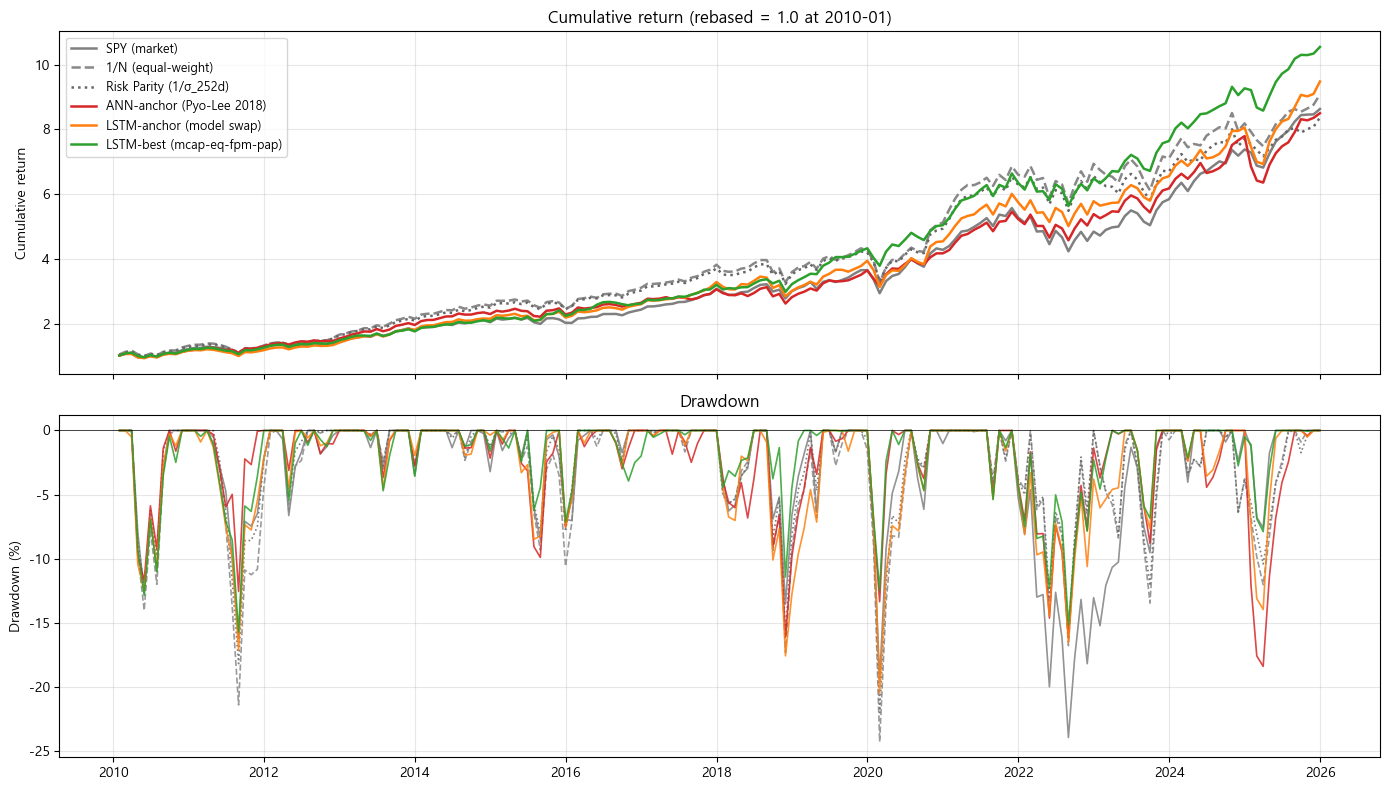

In [21]:
# ── [1b] Benchmark comparison — SPY, 1/N, Risk Parity ─────────
from pathlib import Path

CUTOFF_DT = pd.Timestamp('2025-12-31')

# anchor universe 추출 (월별 valid ticker)
_anchor_w = loaded['mat_mcap_mcap_fpm_pap']['weights']
# panel 에서 vol_252d, fwd_ret_1m 가져오기
_panel = pd.read_csv(DATA_DIR/'monthly_panel.csv', parse_dates=['date'])

def _build_naive_portfolio(weight_mode: str, tc: float = 0.002, max_w: float = 0.10):
    """
    weight_mode: '1N' or 'RP' (risk parity 1/σ_252d)
    universe: each month = anchor weights index 의 non-null ticker
    """
    rets, turns = [], []
    prev_w = None
    for dt in _anchor_w.index:
        if dt > CUTOFF_DT: continue
        # universe = anchor 의 weight 가 nan 이 아닌 종목
        anchor_row = _anchor_w.loc[dt].dropna()
        universe = anchor_row.index.tolist()
        if len(universe) < 20: continue
        # panel 에서 그 월 데이터
        p_row = _panel[(_panel['date']==dt) & (_panel['ticker'].isin(universe))]
        p_row = p_row.dropna(subset=['fwd_ret_1m'])
        if len(p_row) < 20: continue
        valid_tix = p_row['ticker'].tolist()
        ret_vec = p_row.set_index('ticker')['fwd_ret_1m']

        if weight_mode == '1N':
            n = len(valid_tix)
            w = pd.Series(1.0/n, index=valid_tix)
        elif weight_mode == 'RP':
            sig = p_row.set_index('ticker')['vol_252d'].replace(0, np.nan).dropna()
            valid_tix = sig.index.intersection(valid_tix).tolist()
            if len(valid_tix) < 20: continue
            inv = 1.0 / sig.loc[valid_tix]
            w = inv / inv.sum()
            ret_vec = ret_vec.reindex(valid_tix)
        # max weight cap (BL 와 동일)
        w = w.clip(upper=max_w)
        w = w / w.sum()
        # gross return
        ret_vec_aligned = ret_vec.reindex(w.index).fillna(0)
        gross = float((w * ret_vec_aligned).sum())
        # turnover
        if prev_w is not None:
            all_tix = w.index.union(prev_w.index)
            w_a = w.reindex(all_tix).fillna(0)
            pw_a = prev_w.reindex(all_tix).fillna(0)
            turn = float((w_a - pw_a).abs().sum())
        else:
            turn = 0.0
        net = gross - turn*tc
        rets.append((dt, net))
        turns.append((dt, turn))
        prev_w = w
    s = pd.Series({d:r for d,r in rets}).sort_index()
    return s

print('Computing 1/N and Risk Parity portfolios ...')
ret_1n = _build_naive_portfolio('1N')
ret_rp = _build_naive_portfolio('RP')
print(f'  1/N: {len(ret_1n)} months, mean={ret_1n.mean()*100:+.3f}%')
print(f'  RP : {len(ret_rp)} months, mean={ret_rp.mean()*100:+.3f}%')

# SPY return (anchor pkl 의 spy_ret)
ret_spy = loaded['mat_mcap_mcap_fpm_pap']['spy_ret'].dropna()

# BL 슬롯 return
BL_SLOTS = {
    'ANN-anchor (Pyo-Lee 2018)':      'mat_mcap_mcap_fpm_pap_ann',
    'LSTM-anchor (model swap)':       'mat_mcap_mcap_fpm_pap',
    'LSTM-best (mcap-eq-fpm-pap)':   'mat_mcap_eq_fpm_pap',
}
def _bl_ret(name):
    return loaded[name]['ret'].dropna()

# Metric 계산 함수 (rf=0 가정, monthly)
PERIODS_B = [
    ('All', None, None),
    ('R1', '2010-01-01','2012-06-30'),
    ('R2', '2012-07-01','2019-12-31'),
    ('R3', '2020-01-01','2023-06-30'),
    ('R4', '2023-07-01','2025-12-31'),
]
def _metrics(s, st, et):
    r = s.dropna()
    if st: r = r[r.index>=st]
    if et: r = r[r.index<=et]
    if len(r)<6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std()*np.sqrt(12)
    sh  = float(exc.mean()*12/vol) if vol>0 else np.nan
    dn  = r[r<0].std()*np.sqrt(12)
    so  = float(exc.mean()*12/dn) if (dn and dn>0) else np.nan
    cum = (1+r).cumprod()
    mdd = float((cum/cum.cummax()-1).min())
    return dict(Sharpe=sh, Sortino=so, MDD=mdd)

# strategy 목록
STRATS = [
    ('SPY (market)',               ret_spy),
    ('1/N (equal-weight)',         ret_1n),
    ('Risk Parity (1/σ_252d)',     ret_rp),
] + [(lbl, _bl_ret(nm)) for lbl, nm in BL_SLOTS.items()]

# 표 출력
print('\n' + '='*100)
print('Benchmark comparison — Sharpe (Sortino) [MDD] × period')
print('='*100)
hdr = f'{"strategy":<32s}' + ''.join(f'{p:>14s}' for p,_,_ in PERIODS_B)
print(hdr); print('-'*len(hdr))
all_metrics = {}
for label, s in STRATS:
    row = []
    metrics_p = {}
    for p, st, et in PERIODS_B:
        m = _metrics(s, st, et)
        if m:
            row.append(f'{m["Sharpe"]:+.2f}({m["Sortino"]:+.2f})')
            metrics_p[p] = m
        else:
            row.append('       —     ')
    print(f'{label:<32s}' + ''.join(f'{c:>14s}' for c in row))
    all_metrics[label] = metrics_p

# MDD 별도 표
print('\n' + '='*100)
print('MDD (max drawdown) × period')
print('='*100)
print(hdr); print('-'*len(hdr))
for label, s in STRATS:
    row = []
    for p, st, et in PERIODS_B:
        m = all_metrics.get(label, {}).get(p)
        row.append(f'{m["MDD"]*100:+.2f}%' if m else '   —   ')
    print(f'{label:<32s}' + ''.join(f'{c:>14s}' for c in row))

# 누적수익률 + drawdown chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
colors_map = {
    'SPY (market)':                'gray',
    '1/N (equal-weight)':          '#888888',
    'Risk Parity (1/σ_252d)':      '#666666',
    'ANN-anchor (Pyo-Lee 2018)':   '#d62728',
    'LSTM-anchor (model swap)':    '#ff7f0e',
    'LSTM-best (mcap-eq-fpm-pap)': '#2ca02c',
}
linestyles = {
    'SPY (market)': '-',
    '1/N (equal-weight)': '--',
    'Risk Parity (1/σ_252d)': ':',
    'ANN-anchor (Pyo-Lee 2018)': '-',
    'LSTM-anchor (model swap)': '-',
    'LSTM-best (mcap-eq-fpm-pap)': '-',
}
for label, s in STRATS:
    s2 = s[s.index<=CUTOFF_DT].dropna()
    if len(s2)<6: continue
    cum = (1+s2).cumprod()
    ax1.plot(cum.index, cum.values, lw=1.8, label=label,
              color=colors_map.get(label,'black'),
              linestyle=linestyles.get(label,'-'))
    dd = cum / cum.cummax() - 1
    ax2.plot(dd.index, dd.values*100, lw=1.2,
              color=colors_map.get(label,'black'),
              linestyle=linestyles.get(label,'-'),
              alpha=0.85)

ax1.set_title('Cumulative return (rebased = 1.0 at 2010-01)')
ax1.set_ylabel('Cumulative return')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)
ax2.set_title('Drawdown')
ax2.set_ylabel('Drawdown (%)')
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', lw=0.5)
plt.tight_layout()
plt.show()


## [2] 1-step variation × (전체 + 4 레짐) 통합 표

**Anchor (Pyo & Lee 2018)**: `mat_mcap_mcap_fpm_pap` (prior=mcap, p_w=mcap, q=fpm, Ω=pap)

Anchor 에서 한 component 만 변경:

- **SET 1 (Q only)**: prior=mcap, p_w=mcap 고정 → q ∈ {lam, raw, inv, vsp, fpm★}
- **SET 2 (P only)**: prior=mcap, q=fpm 고정 → p_w ∈ {mcap★, eq, rp}
- **SET 3 (Prior only)**: p_w=mcap, q=fpm 고정 → prior ∈ {mcap★, eq, rp}
- **SET 4 (Omega only)**: prior=mcap, p_w=mcap, q=fpm 고정 → Ω ∈ {pap★, he}

총 13 pair (★ = anchor). 

**표 구성**: 한 표에 (All + R1/R2/R3/R4) × (LSTM | ANN | Δ) 통합. 슬롯별 전체 claim 강도와 regime transmission 한눈에 비교.

- 표 1: Sharpe (risk-adjusted return)
- 표 2: Sortino (downside risk-adjusted)
- 표 3: MDD (maximum drawdown, negative; Δ > 0 = LSTM 덜 빠짐)
- 셀 색상: Δ > 0 green / Δ < 0 red (Sharpe, Sortino, MDD 모두 동일 — LSTM 우위 = green)

**Regime 길이**: R1 30mo, R2 90mo, R3 42mo, R4 30mo


In [3]:
# ── [1] 1-step variation × (All + R1/R2/R3/R4) 통합 표 ─────────────
from IPython.display import display


def _calc_metrics(name, start=None, end=None):
    """Sharpe, Sortino, MDD 계산. 기간 미지정 시 전체."""
    if name not in loaded: return None
    ret = loaded[name].get('ret')
    if not isinstance(ret, pd.Series): return None
    r = ret.dropna()
    r = r[r.index <= CUTOFF]
    if start is not None: r = r[r.index >= start]
    if end is not None:   r = r[r.index <= end]
    if len(r) < 6: return None
    rfa = rf.reindex(r.index).fillna(0)
    exc = r - rfa
    vol = r.std() * np.sqrt(12)
    sh  = float(exc.mean() * 12 / vol) if vol > 0 else np.nan
    dn  = r[r < 0].std() * np.sqrt(12)
    so  = float(exc.mean() * 12 / dn) if (dn and dn > 0) else np.nan
    cum = (1 + r).cumprod()
    mdd = float((cum / cum.cummax() - 1).min())
    return dict(Sharpe=sh, Sortino=so, MDD=mdd)


SETS = {
    'SET 1: Q (prior=mcap, p_w=mcap)': [
        ('q=lam',        'mat_mcap_mcap_lam_pap', 'mat_mcap_mcap_lam_pap_ann'),
        ('q=raw',        'mat_mcap_mcap_raw_pap', 'mat_mcap_mcap_raw_pap_ann'),
        ('q=inv',        'mat_mcap_mcap_inv_pap', 'mat_mcap_mcap_inv_pap_ann'),
        ('q=vsp',        'mat_mcap_mcap_vsp_pap', 'mat_mcap_mcap_vsp_pap_ann'),
        ('q=fpm ★',      ANCHOR_L,                ANCHOR_A),
    ],
    'SET 2: P (prior=mcap, q=fpm)': [
        ('p_w=mcap ★',   ANCHOR_L,              ANCHOR_A),
        ('p_w=eq',       'mat_mcap_eq_fpm_pap', 'mat_mcap_eq_fpm_pap_ann'),
        ('p_w=rp',       'mat_mcap_rp_fpm_pap', 'mat_mcap_rp_fpm_pap_ann'),
    ],
    'SET 3: Prior (p_w=mcap, q=fpm)': [
        ('prior=mcap ★', ANCHOR_L,              ANCHOR_A),
        ('prior=eq',     'mat_eq_mcap_fpm_pap', 'mat_eq_mcap_fpm_pap_ann'),
        ('prior=rp',     'mat_rp_mcap_fpm_pap', 'mat_rp_mcap_fpm_pap_ann'),
    ],
    'SET 4: Omega (prior=mcap, p_w=mcap, q=fpm)': [
        ('omega=pap ★',  ANCHOR_L,               ANCHOR_A),
        ('omega=he',     'mat_mcap_mcap_fpm_he', 'mat_mcap_mcap_fpm_he_ann'),
    ],
}

PERIODS = [
    ('All', None,         None),
    ('R1',  '2010-01-01', '2012-06-30'),
    ('R2',  '2012-07-01', '2019-12-31'),
    ('R3',  '2020-01-01', '2023-06-30'),
    ('R4',  '2023-07-01', '2025-12-31'),
]

# 모든 슬롯 × 모든 기간 metric 수집
rows_idx, data_sh, data_so, data_md = [], [], [], []
for set_name, pairs in SETS.items():
    set_id = set_name.split(':')[0]   # 'SET 1' ...
    for label, L_name, A_name in pairs:
        rows_idx.append((set_id, label))
        row_sh, row_so, row_md = [], [], []
        for plbl, s, e in PERIODS:
            mL = _calc_metrics(L_name, s, e)
            mA = _calc_metrics(A_name, s, e)
            if mL and mA:
                row_sh.extend([mL['Sharpe'],  mA['Sharpe'],  mL['Sharpe']-mA['Sharpe']])
                row_so.extend([mL['Sortino'], mA['Sortino'], mL['Sortino']-mA['Sortino']])
                row_md.extend([mL['MDD'],     mA['MDD'],     mL['MDD']-mA['MDD']])
            else:
                row_sh.extend([np.nan]*3); row_so.extend([np.nan]*3); row_md.extend([np.nan]*3)
        data_sh.append(row_sh); data_so.append(row_so); data_md.append(row_md)

cols  = pd.MultiIndex.from_product(
            [[p for p,_,_ in PERIODS], ['L','A','Δ']], names=['period','col'])
idx   = pd.MultiIndex.from_tuples(rows_idx, names=['SET','pair'])
df_sh = pd.DataFrame(data_sh, index=idx, columns=cols)
df_so = pd.DataFrame(data_so, index=idx, columns=cols)
df_md = pd.DataFrame(data_md, index=idx, columns=cols)

period_lbls = [p for p,_,_ in PERIODS]

# ── (1) SET × 기간 LSTM 우위 카운트 (Sharpe) ────────────────────
print('='*70)
print('LSTM 우위 카운트 (Sharpe Δ > 0)')
print('='*70)
hdr = f'{"":<10s}' + ''.join(f'{p:>10s}' for p in period_lbls)
print(hdr); print('-'*len(hdr))
for set_id in ['SET 1','SET 2','SET 3','SET 4']:
    sub = df_sh.loc[set_id]; n_pair = len(sub)
    cells = [f'{int((sub[(p,"Δ")] > 0).sum())}/{n_pair}' for p in period_lbls]
    print(f'{set_id:<10s}' + ''.join(f'{c:>10s}' for c in cells))
print('-'*len(hdr))
totals = [f'{int((df_sh[(p,"Δ")] > 0).sum())}/{len(df_sh)}' for p in period_lbls]
print(f'{"합계":<8s}' + ''.join(f'{c:>10s}' for c in totals))

# 기간별 binomial p-value (one-sided)
print('\n기간별 binomial p-value (H0: p=0.5, one-sided)')
n = len(df_sh)
for p in period_lbls:
    w  = int((df_sh[(p,'Δ')] > 0).sum())
    pv = sum(math.comb(n,k) * 0.5**n for k in range(w, n+1))
    print(f'  {p:>4s}: LSTM win={w}/{n}, p={pv:.3f}')
print('='*70)

# ── (2) SET × 기간 평균 Δ (Sharpe / Sortino / MDD) ───────────────
hdr = f'{"":<10s}' + ''.join(f'{p:>11s}' for p in period_lbls)
for metric_name, df_m, fmt_str in [('Sharpe',  df_sh, '+.3f'),
                                    ('Sortino', df_so, '+.3f'),
                                    ('MDD',     df_md, '+.2%')]:
    print(f'\n평균 Δ_{metric_name} (SET × 기간)')
    print(hdr); print('-'*len(hdr))
    for set_id in ['SET 1','SET 2','SET 3','SET 4']:
        sub = df_m.loc[set_id]
        cells = [f'{sub[(p,"Δ")].mean():{fmt_str}}' for p in period_lbls]
        print(f'{set_id:<10s}' + ''.join(f'{c:>11s}' for c in cells))

# ── (3) 통합 표 (Sharpe + Sortino + MDD) ─────────────────────────
def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

delta_cols = [(p,'Δ') for p in period_lbls]
fmt_ratio  = {col: ('{:+.3f}' if col[1]=='Δ' else '{:.3f}') for col in df_sh.columns}
fmt_pct    = {col: ('{:+.2%}' if col[1]=='Δ' else '{:.2%}') for col in df_md.columns}

print('\n[표 1] Sharpe (LSTM | ANN | Δ) × (All + R1-R4)')
display(df_sh.style.format(fmt_ratio).map(_hl, subset=delta_cols))

print('\n[표 2] Sortino (LSTM | ANN | Δ) × (All + R1-R4)')
display(df_so.style.format(fmt_ratio).map(_hl, subset=delta_cols))

print('\n[표 3] MDD (LSTM | ANN | Δ) × (All + R1-R4)  ← Δ>0 = LSTM 덜 빠짐')
df_md.style.format(fmt_pct).map(_hl, subset=delta_cols)


LSTM 우위 카운트 (Sharpe Δ > 0)
                 All        R1        R2        R3        R4
------------------------------------------------------------
SET 1            3/5       0/5       2/5       4/5       3/5
SET 2            3/3       0/3       3/3       2/3       3/3
SET 3            3/3       0/3       3/3       0/3       3/3
SET 4            1/2       0/2       2/2       0/2       1/2
------------------------------------------------------------
합계           10/13      0/13     10/13      6/13     10/13

기간별 binomial p-value (H0: p=0.5, one-sided)
   All: LSTM win=10/13, p=0.046
    R1: LSTM win=0/13, p=1.000
    R2: LSTM win=10/13, p=0.046
    R3: LSTM win=6/13, p=0.709
    R4: LSTM win=10/13, p=0.046

평균 Δ_Sharpe (SET × 기간)
                  All         R1         R2         R3         R4
-----------------------------------------------------------------
SET 1          -0.007     -0.232     -0.057     +0.188     +0.035
SET 2          +0.045     -0.159     +0.086     +0.063     +0.


[표 2] Sortino (LSTM | ANN | Δ) × (All + R1-R4)



[표 3] MDD (LSTM | ANN | Δ) × (All + R1-R4)  ← Δ>0 = LSTM 덜 빠짐


### [2] 해석 요약

1. **P 행렬 (mcap → eq, rp) — 큰 폭 상승**
   LSTM/ANN 모두 절대 Sharpe/Sortino 가 크게 상승. p_w 를 동일가중 (eq) 또는 위험가중 (rp) 으로 두면 portfolio 분산 효과 강화 → market-cap 집중 완화. SET 2 LSTM win 3/3 (All).

2. **Q (양수 view) — 금융위기 포함 레짐 (R3) 좋은 성능**
   R3 에서 SET 1 (Q 변화) mean Δ_Sharpe **+0.188** (전 SET 중 최대), LSTM win **4/5**.

3. **R1 (회복) 일관적 LSTM 약세**
   4 SET 모두 R1 LSTM win **0/n**, 합계 **0/13**, p=1.000.

4. **Prior 방향성 부재**
   prior ∈ {mcap, eq, rp} 변화는 일관된 LSTM 우위 패턴 없음. SET 3 는 All 3/3 이지만 R1=0/3, R2=3/3, R3=0/3, R4=3/3 으로 레짐별 부호 반전. Q의 fpm의 설정 부호와 동일한 것으로 보아, prior 보다는 Q와 P의 영향이 클 것으로 예상.

5. **Omega: paper > He (1999)**
   대부분 슬롯에서 ω=pap (Idzorek-style, Pyo-Lee 채택) 이 ω=he 보다 좋은 절대 성능.


## [3] P 행렬 변경 (mcap, eq, rp) × 모든 슬롯 grid

**목적**: P 행렬 가중 (p_w) 을 mcap → eq → rp 로 바꿨을 때, 다른 차원 (prior, q) 의 모든 조합에서 LSTM 우위가 robust 한가?

**Grid** (45 슬롯):
- p_w ∈ {mcap, eq, rp}
- prior ∈ {mcap, eq, rp}
- q ∈ {lam, raw, inv, vsp, fpm} (fix 제외)
- omega = pap 고정 (he 제거 — [2] 에서 pap > he 확인됨)

전체 (All) + R1/R2/R3/R4 레짐별 Sharpe (LSTM | ANN | Δ).

**색상 규칙**: Δ > 0 (LSTM 우위) green / Δ < 0 (ANN 우위) red


In [4]:
# ── [3] P 행렬 × 모든 슬롯 grid (45 슬롯, omega=pap) ───────────────
from IPython.display import display

# 차원
PRIORS    = ['mcap', 'eq', 'rp']
P_WEIGHTS = ['mcap', 'eq', 'rp']
Q_MODES   = ['lam', 'raw', 'inv', 'vsp', 'fpm']
OMEGA     = 'pap'   # 고정

# 45 슬롯 (p_w 외곽, mcap→eq→rp 순서)
slots = [(pw, pr, q)
         for pw in P_WEIGHTS
         for pr in PRIORS
         for q  in Q_MODES]

# 각 슬롯 × 기간 metric (Sharpe / Sortino / MDD)
rows_idx, data_sh, data_so, data_md = [], [], [], []
missing = []
for pw, pr, q in slots:
    L_name = f'mat_{pr}_{pw}_{q}_{OMEGA}'
    A_name = L_name + '_ann'
    if L_name not in loaded or A_name not in loaded:
        missing.append(L_name); continue
    rows_idx.append((pw, pr, q))
    row_sh, row_so, row_md = [], [], []
    for plbl, s, e in PERIODS:
        mL = _calc_metrics(L_name, s, e)
        mA = _calc_metrics(A_name, s, e)
        if mL and mA:
            row_sh.extend([mL['Sharpe'],  mA['Sharpe'],  mL['Sharpe']-mA['Sharpe']])
            row_so.extend([mL['Sortino'], mA['Sortino'], mL['Sortino']-mA['Sortino']])
            row_md.extend([mL['MDD'],     mA['MDD'],     mL['MDD']-mA['MDD']])
        else:
            row_sh.extend([np.nan]*3); row_so.extend([np.nan]*3); row_md.extend([np.nan]*3)
    data_sh.append(row_sh); data_so.append(row_so); data_md.append(row_md)

if missing:
    print(f'missing {len(missing)}: {missing[:5]} ...')
print(f'슬롯 수: {len(rows_idx)} (예상 45)')

cols_p = pd.MultiIndex.from_product(
            [[p for p,_,_ in PERIODS], ['L','A','Δ']], names=['period','col'])
idx_p  = pd.MultiIndex.from_tuples(rows_idx, names=['p_w','prior','q'])
df_p_sh = pd.DataFrame(data_sh, index=idx_p, columns=cols_p)
df_p_so = pd.DataFrame(data_so, index=idx_p, columns=cols_p)
df_p_md = pd.DataFrame(data_md, index=idx_p, columns=cols_p)
# 순서 유지 (mcap, eq, rp) — sort_index 호출 X

period_lbls = [p for p,_,_ in PERIODS]

# ── (1) p_w × 기간 LSTM 우위 카운트 (Sharpe / Sortino / MDD) ─────
print('\n' + '='*70)
print('P 행렬 × 기간 LSTM 우위 카운트 (Δ > 0)')
print('='*70)
hdr = f'{"":<14s}' + ''.join(f'{p:>10s}' for p in period_lbls)
for metric_name, df_m in [('Sharpe', df_p_sh), ('Sortino', df_p_so), ('MDD', df_p_md)]:
    print(f'\n[{metric_name}]')
    print(hdr); print('-'*len(hdr))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]; n_pair = len(sub)
        cells = [f'{int((sub[(p,"Δ")] > 0).sum())}/{n_pair}' for p in period_lbls]
        print(f'p_w={pw:<10s}' + ''.join(f'{c:>10s}' for c in cells))
    totals = [f'{int((df_m[(p,"Δ")] > 0).sum())}/{len(df_m)}' for p in period_lbls]
    print(f'{"합계":<12s}' + ''.join(f'{c:>10s}' for c in totals))

# ── (2) p_w × 기간 평균 절대값 (LSTM | ANN) ─────────────────────
print('\n' + '='*86)
print('평균 절대값 (p_w × 기간) — LSTM | ANN')
print('='*86)
for metric_name, df_m, fmt_v in [('Sharpe',  df_p_sh, '5.3f'),
                                  ('Sortino', df_p_so, '5.3f'),
                                  ('MDD',     df_p_md, '6.2%')]:
    print(f'\n[{metric_name}]')
    hdr2 = f'{"":<14s}' + ''.join(f'{p:>16s}' for p in period_lbls)
    print(hdr2); print('-'*len(hdr2))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]
        cells = []
        for p in period_lbls:
            mL = sub[(p,'L')].mean()
            mA = sub[(p,'A')].mean()
            cells.append(f'{mL:>{fmt_v}}|{mA:{fmt_v}}')
        print(f'p_w={pw:<10s}' + ''.join(f'{c:>16s}' for c in cells))

# ── (3) p_w × 기간 평균 Δ ───────────────────────────────────────
print('\n' + '='*70)
print('평균 Δ (p_w × 기간) — + = LSTM 우위 (MDD: Δ>0 = LSTM 덜 빠짐)')
print('='*70)
for metric_name, df_m, fmt_d in [('Sharpe',  df_p_sh, '+.3f'),
                                  ('Sortino', df_p_so, '+.3f'),
                                  ('MDD',     df_p_md, '+.2%')]:
    print(f'\n[{metric_name}]')
    hdr3 = f'{"":<14s}' + ''.join(f'{p:>11s}' for p in period_lbls)
    print(hdr3); print('-'*len(hdr3))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]
        cells = [f'{sub[(p,"Δ")].mean():{fmt_d}}' for p in period_lbls]
        print(f'p_w={pw:<10s}' + ''.join(f'{c:>11s}' for c in cells))

# ── (4) Full grid 통합 표 (3 metric) ────────────────────────────
def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

delta_cols_p = [(p,'Δ') for p in period_lbls]
fmt_ratio    = {col: ('{:+.3f}' if col[1]=='Δ' else '{:.3f}') for col in df_p_sh.columns}
fmt_pct      = {col: ('{:+.2%}' if col[1]=='Δ' else '{:.2%}') for col in df_p_md.columns}

print('\n[표 1] Sharpe (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯')
display(df_p_sh.style.format(fmt_ratio).map(_hl, subset=delta_cols_p))

print('\n[표 2] Sortino (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯')
display(df_p_so.style.format(fmt_ratio).map(_hl, subset=delta_cols_p))

print('\n[표 3] MDD (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯  ← Δ>0 = LSTM 덜 빠짐')
df_p_md.style.format(fmt_pct).map(_hl, subset=delta_cols_p)


슬롯 수: 45 (예상 45)

P 행렬 × 기간 LSTM 우위 카운트 (Δ > 0)

[Sharpe]
                     All        R1        R2        R3        R4
----------------------------------------------------------------
p_w=mcap            5/15      0/15      5/15     12/15      7/15
p_w=eq             15/15      1/15      5/15     15/15     15/15
p_w=rp             15/15     14/15      9/15     15/15     15/15
합계               35/45     15/45     19/45     42/45     37/45

[Sortino]
                     All        R1        R2        R3        R4
----------------------------------------------------------------
p_w=mcap            4/15      0/15      3/15     12/15     10/15
p_w=eq             15/15     12/15      3/15     15/15     15/15
p_w=rp             15/15     15/15      7/15     15/15     15/15
합계               34/45     27/45     13/45     42/45     40/45

[MDD]
                     All        R1        R2        R3        R4
----------------------------------------------------------------
p_w=mcap          


[표 2] Sortino (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯



[표 3] MDD (LSTM | ANN | Δ) × (All + R1-R4) — 45 슬롯  ← Δ>0 = LSTM 덜 빠짐


## [3b] P 행렬 × 모든 슬롯 grid — R1-R3 sample (R4 제외)

**목적**: [3] 의 동일 분석을 **R4 (AI 랠리, 2023-07~2025-12) 제외** 한 sample (2010-01~2023-06, 162 months) 에서 재확인.

- R4 의 구조적 특수성 (AI 랠리 / Mag7 집중) 이 grid 패턴에 미치는 영향 확인용
- main 본문엔 안 들어감 (sample cutting). discussion / appendix evidence 로만 사용


In [10]:
# ── [3b] P 행렬 × 모든 슬롯 grid — R1-R3 sample (R4 제외) ───────
from IPython.display import display

PERIODS_R13 = [
    ('All_R1-R3', '2010-01-01', '2023-06-30'),
    ('R1',        '2010-01-01', '2012-06-30'),
    ('R2',        '2012-07-01', '2019-12-31'),
    ('R3',        '2020-01-01', '2023-06-30'),
]

PRIORS    = ['mcap', 'eq', 'rp']
P_WEIGHTS = ['mcap', 'eq', 'rp']
Q_MODES   = ['lam', 'raw', 'inv', 'vsp', 'fpm']
OMEGA     = 'pap'

slots = [(pw, pr, q)
         for pw in P_WEIGHTS
         for pr in PRIORS
         for q  in Q_MODES]

rows_idx, data_sh, data_so, data_md = [], [], [], []
for pw, pr, q in slots:
    L_name = f'mat_{pr}_{pw}_{q}_{OMEGA}'
    A_name = L_name + '_ann'
    if L_name not in loaded or A_name not in loaded: continue
    rows_idx.append((pw, pr, q))
    row_sh, row_so, row_md = [], [], []
    for plbl, s, e in PERIODS_R13:
        mL = _calc_metrics(L_name, s, e)
        mA = _calc_metrics(A_name, s, e)
        if mL and mA:
            row_sh.extend([mL['Sharpe'],  mA['Sharpe'],  mL['Sharpe']-mA['Sharpe']])
            row_so.extend([mL['Sortino'], mA['Sortino'], mL['Sortino']-mA['Sortino']])
            row_md.extend([mL['MDD'],     mA['MDD'],     mL['MDD']-mA['MDD']])
        else:
            row_sh.extend([np.nan]*3); row_so.extend([np.nan]*3); row_md.extend([np.nan]*3)
    data_sh.append(row_sh); data_so.append(row_so); data_md.append(row_md)

print(f'슬롯 수: {len(rows_idx)} (예상 45)')

cols_p = pd.MultiIndex.from_product(
            [[p for p,_,_ in PERIODS_R13], ['L','A','Δ']], names=['period','col'])
idx_p  = pd.MultiIndex.from_tuples(rows_idx, names=['p_w','prior','q'])
df_p_sh = pd.DataFrame(data_sh, index=idx_p, columns=cols_p)
df_p_so = pd.DataFrame(data_so, index=idx_p, columns=cols_p)
df_p_md = pd.DataFrame(data_md, index=idx_p, columns=cols_p)

period_lbls = [p for p,_,_ in PERIODS_R13]

# (1) p_w × 기간 LSTM 우위 카운트
print('\n' + '='*70)
print('P 행렬 × 기간 LSTM 우위 카운트 (Δ > 0) — R4 제외 sample')
print('='*70)
hdr = f'{"":<14s}' + ''.join(f'{p:>12s}' for p in period_lbls)
for metric_name, df_m in [('Sharpe', df_p_sh), ('Sortino', df_p_so), ('MDD', df_p_md)]:
    print(f'\n[{metric_name}]')
    print(hdr); print('-'*len(hdr))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]; n_pair = len(sub)
        cells = [f'{int((sub[(p,"Δ")] > 0).sum())}/{n_pair}' for p in period_lbls]
        print(f'p_w={pw:<10s}' + ''.join(f'{c:>12s}' for c in cells))
    totals = [f'{int((df_m[(p,"Δ")] > 0).sum())}/{len(df_m)}' for p in period_lbls]
    print(f'{"합계":<12s}' + ''.join(f'{c:>12s}' for c in totals))

# (2) p_w × 기간 평균 절대값
print('\n' + '='*86)
print('평균 절대값 (p_w × 기간) — LSTM | ANN — R4 제외')
print('='*86)
for metric_name, df_m, fmt_v in [('Sharpe',  df_p_sh, '5.3f'),
                                  ('Sortino', df_p_so, '5.3f'),
                                  ('MDD',     df_p_md, '6.2%')]:
    print(f'\n[{metric_name}]')
    hdr2 = f'{"":<14s}' + ''.join(f'{p+" L":>10s}{p+" A":>10s}{p+" Δ":>10s}' for p in period_lbls)
    print(hdr2); print('-'*len(hdr2))
    for pw in P_WEIGHTS:
        sub = df_m.loc[pw]
        cells = []
        for p in period_lbls:
            mL_avg = sub[(p,"L")].mean()
            mA_avg = sub[(p,"A")].mean()
            mD_avg = sub[(p,"Δ")].mean()
            cells.append(f'{mL_avg:>+10.3f}{mA_avg:>+10.3f}{mD_avg:>+10.3f}'
                          if metric_name != 'MDD'
                          else f'{mL_avg:>+10.2%}{mA_avg:>+10.2%}{mD_avg:>+10.2%}')
        print(f'p_w={pw:<10s}' + ''.join(cells))

# (3) 표시용 styled table — Sharpe
def _hl(v):
    if not isinstance(v, (int, float)) or pd.isna(v): return ''
    if v > 0: return 'background-color: #b8e0b8; color: black; font-weight: bold'
    if v < 0: return 'background-color: #f4b6b6; color: black; font-weight: bold'
    return ''

delta_cols = [(p,'Δ') for p in period_lbls]
fmt_ratio  = {col: ('{:+.3f}' if col[1]=='Δ' else '{:.3f}') for col in df_p_sh.columns}
fmt_pct    = {col: ('{:+.2%}' if col[1]=='Δ' else '{:.2%}') for col in df_p_md.columns}

print('\n[표 1] Sharpe (LSTM | ANN | Δ) × (All_R1-R3 + R1/R2/R3)')
display(df_p_sh.style.format(fmt_ratio).map(_hl, subset=delta_cols))

print('\n[표 2] Sortino (LSTM | ANN | Δ)')
display(df_p_so.style.format(fmt_ratio).map(_hl, subset=delta_cols))

print('\n[표 3] MDD (LSTM | ANN | Δ)  ← Δ>0 = LSTM 덜 빠짐')
df_p_md.style.format(fmt_pct).map(_hl, subset=delta_cols)


슬롯 수: 45 (예상 45)

P 행렬 × 기간 LSTM 우위 카운트 (Δ > 0) — R4 제외 sample

[Sharpe]
                 All_R1-R3          R1          R2          R3
--------------------------------------------------------------
p_w=mcap              2/15        0/15        5/15       12/15
p_w=eq               15/15        1/15        5/15       15/15
p_w=rp               15/15       14/15        9/15       15/15
합계                 32/45       15/45       19/45       42/45

[Sortino]
                 All_R1-R3          R1          R2          R3
--------------------------------------------------------------
p_w=mcap              5/15        0/15        3/15       12/15
p_w=eq               15/15       12/15        3/15       15/15
p_w=rp               15/15       15/15        7/15       15/15
합계                 35/45       27/45       13/45       42/45

[MDD]
                 All_R1-R3          R1          R2          R3
--------------------------------------------------------------
p_w=mcap              1/15     


[표 2] Sortino (LSTM | ANN | Δ)



[표 3] MDD (LSTM | ANN | Δ)  ← Δ>0 = LSTM 덜 빠짐


## [4] Low-vol anomaly per regime check

**목적**: BL framework 의 "long low-vol / short high-vol" view 가 작동하려면 sample 내 low-vol anomaly 가 존재해야 함. SP500 sample 2010-2025 에서 anomaly 가 실제 있는지 확인.

- 매월 cross-sectional 로 σ 상위 30% (high-vol) vs 하위 30% (low-vol) bucket 평균 수익률 비교
- L-H spread (low minus high) 가 양수면 anomaly 작동, null/음수면 부재


In [ ]:
# ── [4] Low-vol anomaly per regime (top/bottom 30%) ──────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
print(f'panel: {len(panel):,} obs')

def _anomaly_lh(df, q=0.30):
    lows, highs = [], []
    for dt, g in df.groupby('date'):
        g = g.dropna(subset=['vol_252d','fwd_ret_1m'])
        if len(g) < 50: continue
        n = max(1, int(len(g)*q))
        lo = g.nsmallest(n,'vol_252d')['fwd_ret_1m'].mean()
        hi = g.nlargest(n, 'vol_252d')['fwd_ret_1m'].mean()
        lows.append(lo); highs.append(hi)
    if not lows: return np.nan, np.nan, np.nan
    L = np.mean(lows); H = np.mean(highs)
    return L, H, L - H

PERIODS_A = [
    ('All',    None,         None),
    ('R1',     '2010-01-01', '2012-06-30'),
    ('R2',     '2012-07-01', '2019-12-31'),
    ('R3',     '2020-01-01', '2023-06-30'),
    ('R4',     '2023-07-01', '2025-12-31'),
]

print('\n' + '='*70)
print('Low-vol anomaly check — SP500 sample, σ_252d 기준 top/bottom 30%')
print('  L-H spread > 0  → low-vol anomaly 작동')
print('  L-H spread ≈ 0  → null')
print('  L-H spread < 0  → 역 anomaly (high-vol 우위)')
print('='*70)
print(f'{"period":<8s}{"Low avg":>12s}{"High avg":>12s}{"L-H spread":>14s}{"n months":>12s}')
print('-'*60)
for lbl, s, e in PERIODS_A:
    sub = panel
    if s: sub = sub[sub['date'] >= s]
    if e: sub = sub[sub['date'] <= e]
    L, H, spr = _anomaly_lh(sub)
    n_mo = sub['date'].nunique() if len(sub) > 0 else 0
    print(f'{lbl:<8s}{L*100:>+11.3f}%{H*100:>+11.3f}%{spr*100:>+13.3f}%{n_mo:>12d}')

print('\n→ SP500 2010-2025 에서 low-vol anomaly null (또는 negative spread).')
print('→ LSTM 의 portfolio 우위가 anomaly capture 로 인한 것이 아님을 시사 (spurious 가설 배제).')


## [5] R1 catastrophic months 분해 (calendar 정렬)

**가설**: R1 LSTM 약세 (특히 mcap p_w) 는 단일 catastrophic month (2011-08 S&P downgrade) 가 dominant.

- pkl 의 ret 는 construction date 기준 indexed → +1 MonthEnd shift 해서 calendar (realization) date 로 정렬
- 45 슬롯 × R1 월별 LSTM-ANN return 차이 분해
- worst 5 months, top 5 worst 제거 시 R1 누적 gap 변화 확인


R1 (calendar) 월 수: 29, 슬롯 수: 45

R1 월별 LSTM-ANN return 차이 (p_w 별 15-슬롯 평균, calendar 기준)
month               mcap            eq            rp        All 45
------------------------------------------------------------------
2010-02          -0.0026       -0.0013       -0.0193       -0.0077
2010-03          -0.0011       +0.0009       +0.0101       +0.0033
2010-04          -0.0082       +0.0013       +0.0037       -0.0011
2010-05          -0.0010       +0.0086       +0.0350       +0.0142
2010-06          +0.0038       -0.0074       +0.0111       +0.0025
2010-07          -0.0027       -0.0012       -0.0053       -0.0031
2010-08          -0.0051       -0.0064       -0.0086       -0.0067
2010-09          +0.0011       +0.0012       +0.0004       +0.0009
2010-10          -0.0004       +0.0007       +0.0006       +0.0003
2010-11          +0.0028       -0.0012       +0.0031       +0.0015
2010-12          +0.0023       +0.0036       +0.0071       +0.0043
2011-01          -0.0003       -0.0010   

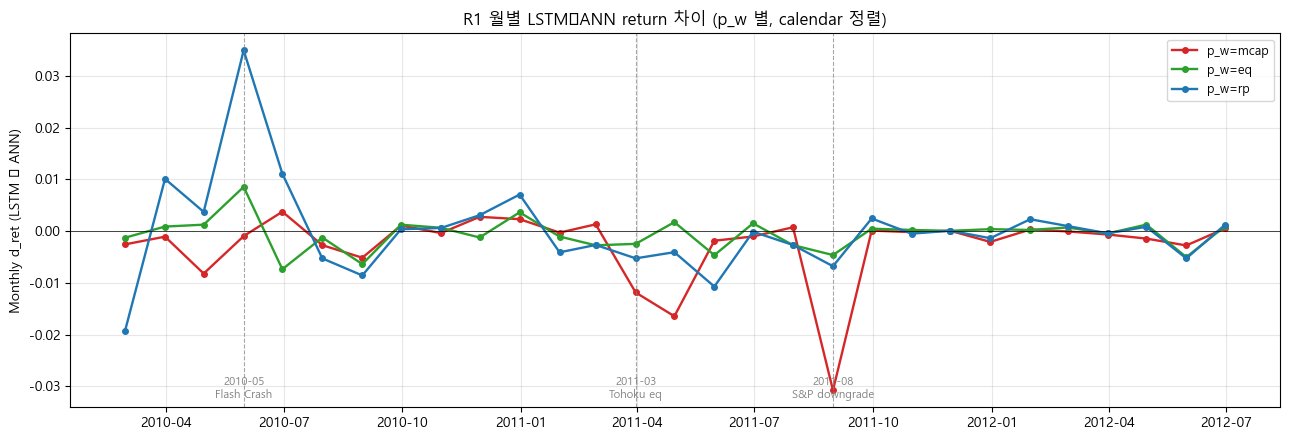

In [15]:
# ── [5] R1 catastrophic months 분해 (calendar 정렬) ─────────────
R1_START = pd.Timestamp('2010-01-31')
R1_END   = pd.Timestamp('2012-06-30')

PRIORS=['mcap','eq','rp']; PW=['mcap','eq','rp']; Q=['lam','raw','inv','vsp','fpm']

diff_data = {}
for pw in PW:
    for pr in PRIORS:
        for q in Q:
            L = f'mat_{pr}_{pw}_{q}_pap'; A = L + '_ann'
            if L not in loaded or A not in loaded: continue
            rL = loaded[L]['ret'].dropna()
            rA = loaded[A]['ret'].dropna()
            common = rL.index.intersection(rA.index)
            d = rL.loc[common] - rA.loc[common]
            d.index = d.index + pd.offsets.MonthEnd(1)
            mask = (d.index >= R1_START) & (d.index <= R1_END)
            diff_data[(pw, pr, q)] = d[mask]

df_diff = pd.DataFrame(diff_data)
print(f'R1 (calendar) 월 수: {len(df_diff)}, 슬롯 수: {df_diff.shape[1]}')

pw_avg  = {pw: df_diff[[c for c in df_diff.columns if c[0]==pw]].mean(axis=1) for pw in PW}
all_avg = df_diff.mean(axis=1)

print('\n' + '='*78)
print('R1 월별 LSTM-ANN return 차이 (p_w 별 15-슬롯 평균, calendar 기준)')
print('='*78)
hdr = f'{"month":<10s}' + ''.join(f'{pw:>14s}' for pw in PW) + f'{"All 45":>14s}'
print(hdr); print('-'*len(hdr))
for dt in df_diff.index:
    row = [pw_avg[pw][dt] for pw in PW]
    print(f'{dt.strftime("%Y-%m"):<10s}' + ''.join(f'{v:>+14.4f}' for v in row) + f'{all_avg[dt]:>+14.4f}')

print('\n' + '='*78)
print('p_w 별 LSTM 최악 월 — worst 5 (calendar month, mean d_ret across 15 slots)')
print('='*78)
for pw in PW:
    worst5 = pw_avg[pw].nsmallest(5)
    print(f'\n[p_w={pw}]')
    for dt, v in worst5.items():
        print(f'  {dt.strftime("%Y-%m"):<10s}: {v:+.4f}')

print('\n' + '='*78)
print('R1 cumulative LSTM-ANN gap — catastrophic months 의 기여도')
print('='*78)
print(f'{"제거 대상":<28s}{"mcap":>12s}{"eq":>12s}{"rp":>12s}')
print('-'*64)

scenarios = [
    ('전체 (제거 없음)',           []),
    ('2011-08 (S&P downgrade)',    ['2011-08']),
    ('2011-08 + 2011-04 + 2011-03', ['2011-08','2011-04','2011-03']),
]
for label, excl_ym in scenarios:
    cells = []
    for pw in PW:
        s = pw_avg[pw]
        if not excl_ym:
            total = s.sum()
        else:
            kept = s[~s.index.strftime('%Y-%m').isin(excl_ym)]
            total = kept.sum()
        cells.append(f'{total:+12.4f}')
    print(f'{label:<28s}' + ''.join(cells))

cells = []
for pw in PW:
    s = pw_avg[pw]
    worst5_idx = s.nsmallest(5).index
    kept = s.drop(worst5_idx)
    cells.append(f'{kept.sum():+12.4f}')
print(f'{"top 5 worst (per p_w) 제거":<28s}' + ''.join(cells))

fig, ax = plt.subplots(figsize=(13, 4.5))
for pw, color in zip(PW, ['#d62728', '#2ca02c', '#1f77b4']):
    ax.plot(pw_avg[pw].index, pw_avg[pw].values, label=f'p_w={pw}',
            color=color, lw=1.7, marker='o', markersize=4)
ax.axhline(0, color='black', lw=0.5)

events = [('2010-05','Flash Crash'),('2011-03','Tohoku eq'),('2011-08','S&P downgrade')]
ylim = ax.get_ylim()
for ym, lbl in events:
    matches = [dt for dt in pw_avg['mcap'].index if dt.strftime('%Y-%m') == ym]
    if matches:
        dt = matches[0]
        ax.axvline(dt, color='gray', ls='--', lw=0.8, alpha=0.7)
        ax.annotate(f'{ym}\n{lbl}', xy=(dt, ylim[0]*0.95),
                    fontsize=8, ha='center', color='gray')

ax.set_title('R1 월별 LSTM−ANN return 차이 (p_w 별, calendar 정렬)')
ax.set_ylabel('Monthly d_ret (LSTM − ANN)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## [6] Q × regime × p_w timeline grid

regime 별로 5 Q 가 세로 stacked, 각 subplot 에 p_w 3 라인. event annotation 포함.

- 5 row (Q: lam/raw/inv/vsp/fpm) × 4 regime (R1/R2/R3/R4) figure
- 각 subplot 의 3 라인 = p_w (mcap/eq/rp) 의 3-prior 평균
- 모든 시간 축은 **calendar 정렬** (+1 MonthEnd shift)


Q × regime 월평균 LSTM−ANN return  (각 셀: 3 prior × 3 p_w = 9 슬롯 평균)
Q                     R1              R2              R3              R4     all (10y)
--------------------------------------------------------------------------------------
lam              -0.0011         -0.0008         +0.0046         +0.0007       +0.0006
raw              -0.0010         -0.0008         +0.0046         +0.0007       +0.0006
inv              -0.0007         -0.0000         +0.0024         +0.0004       +0.0005
vsp              -0.0010         -0.0003         +0.0031         +0.0002       +0.0004
fpm              -0.0016         +0.0011         +0.0014         +0.0012       +0.0008


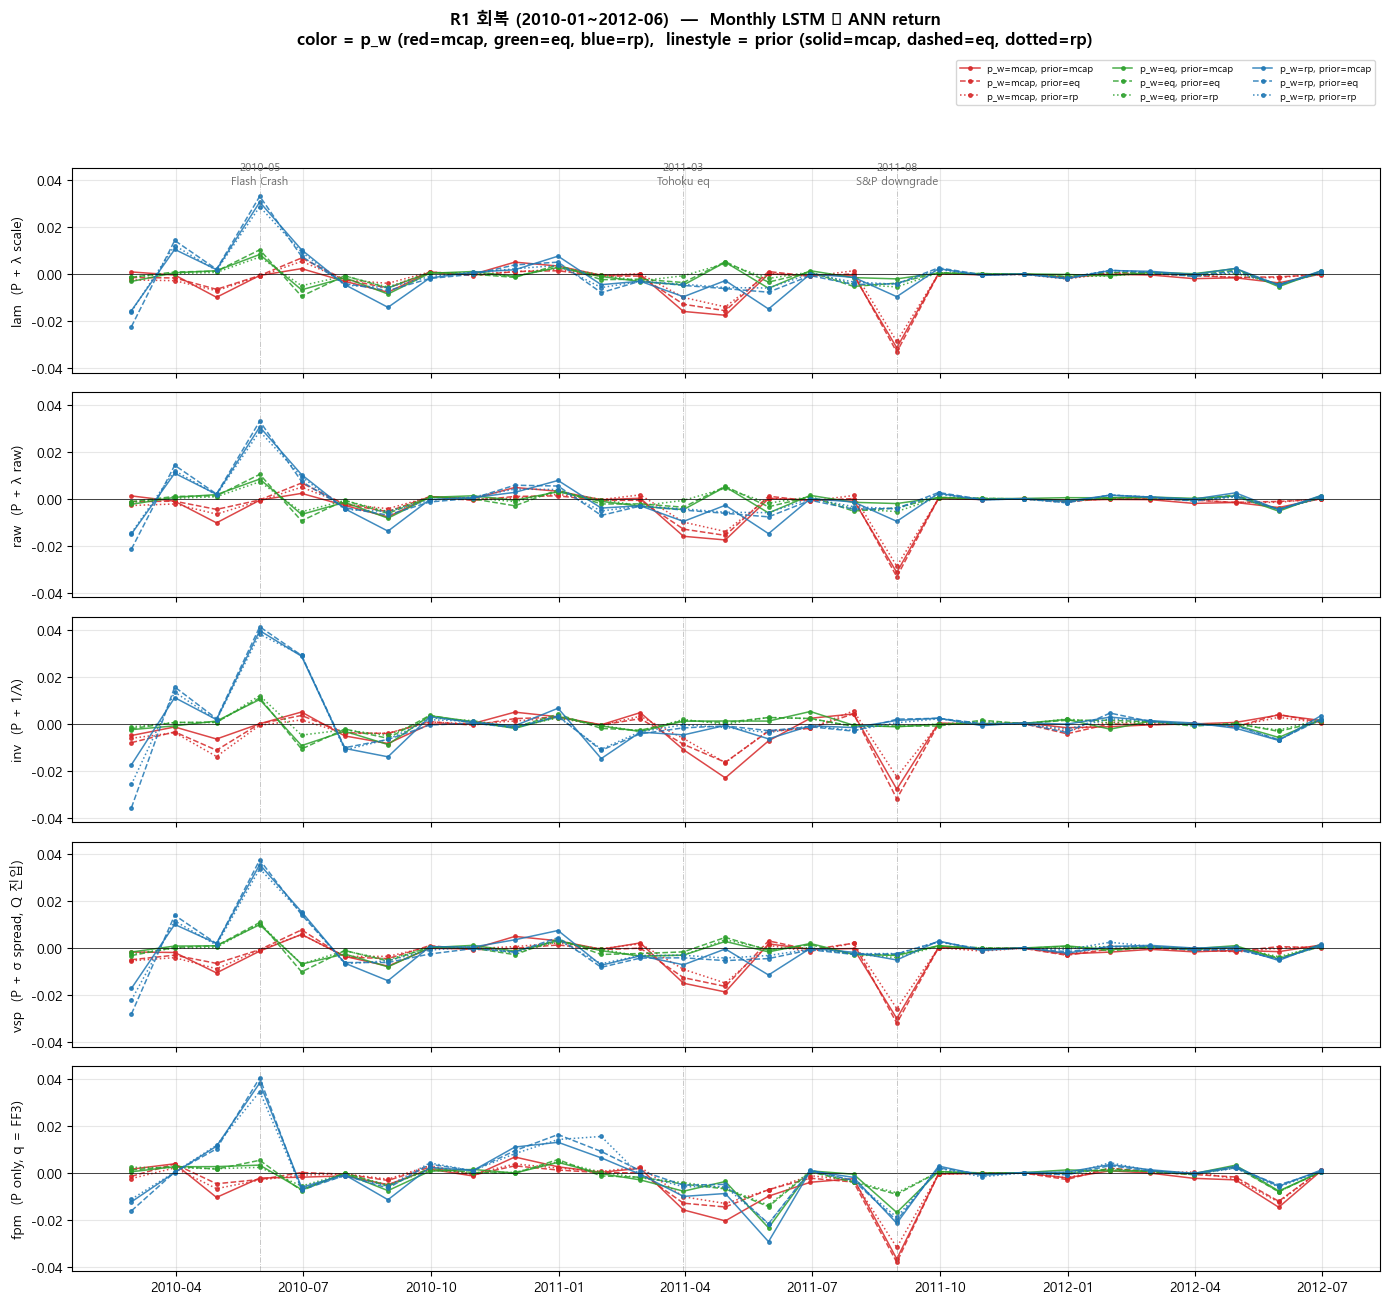

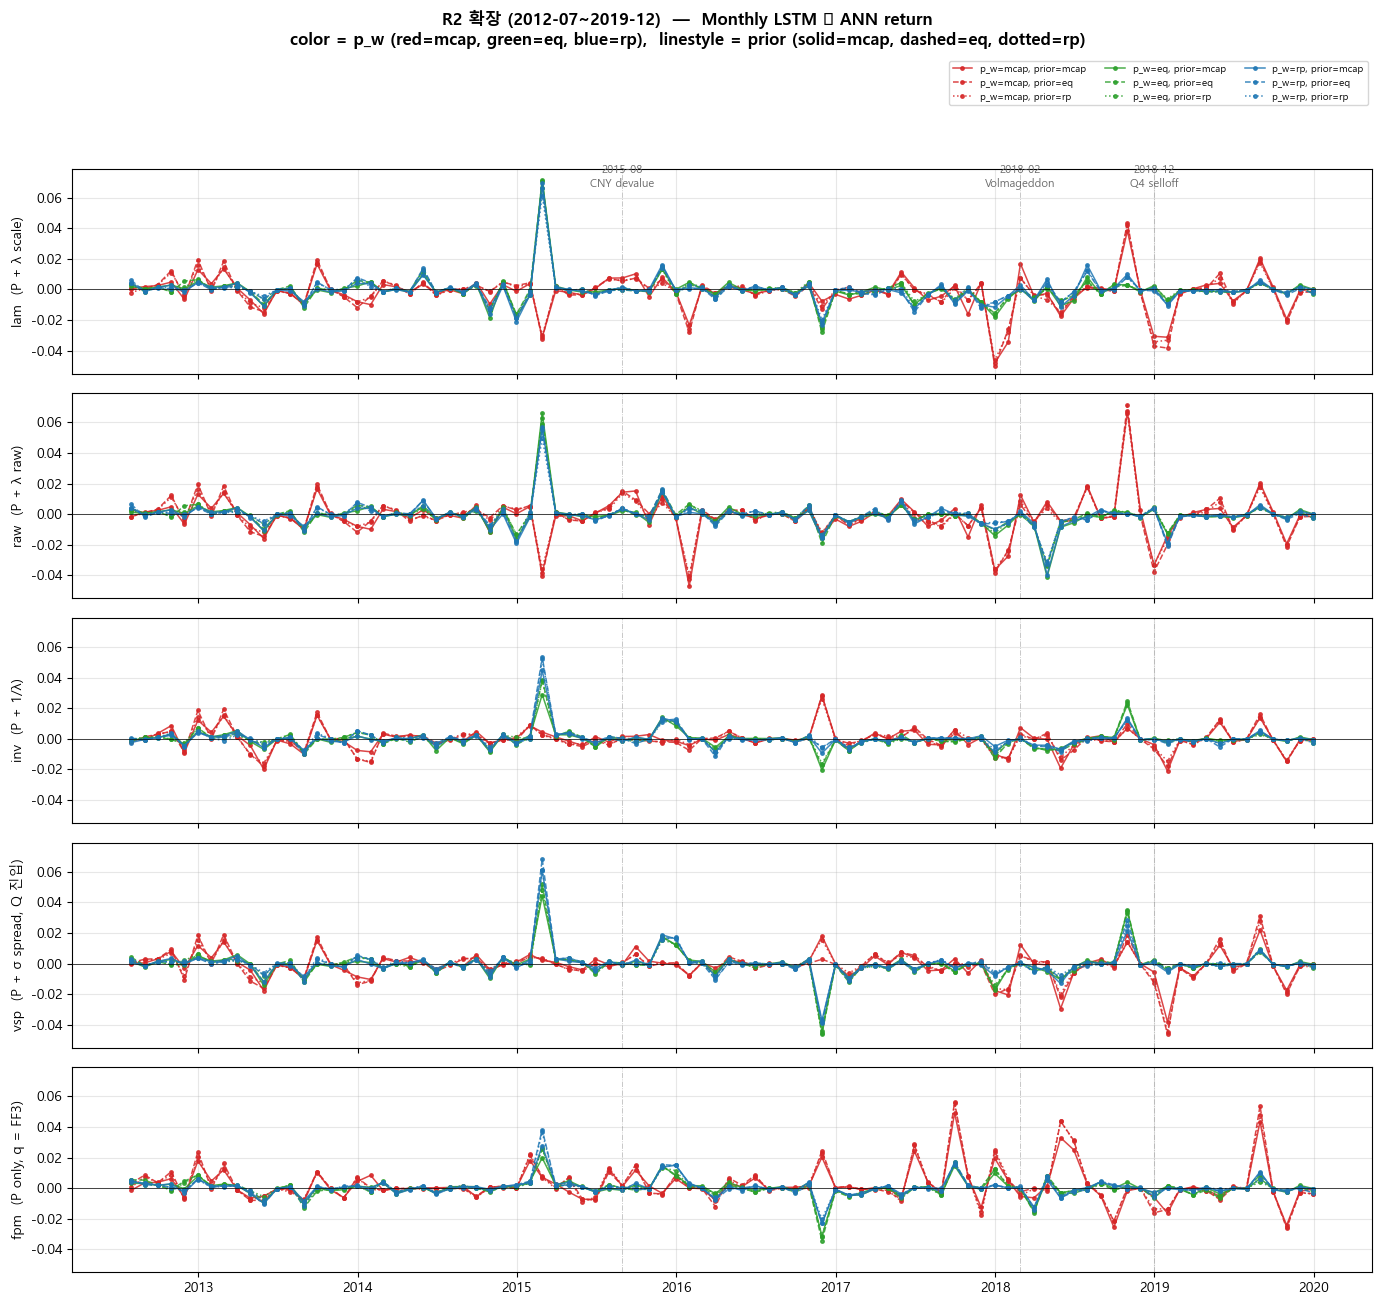

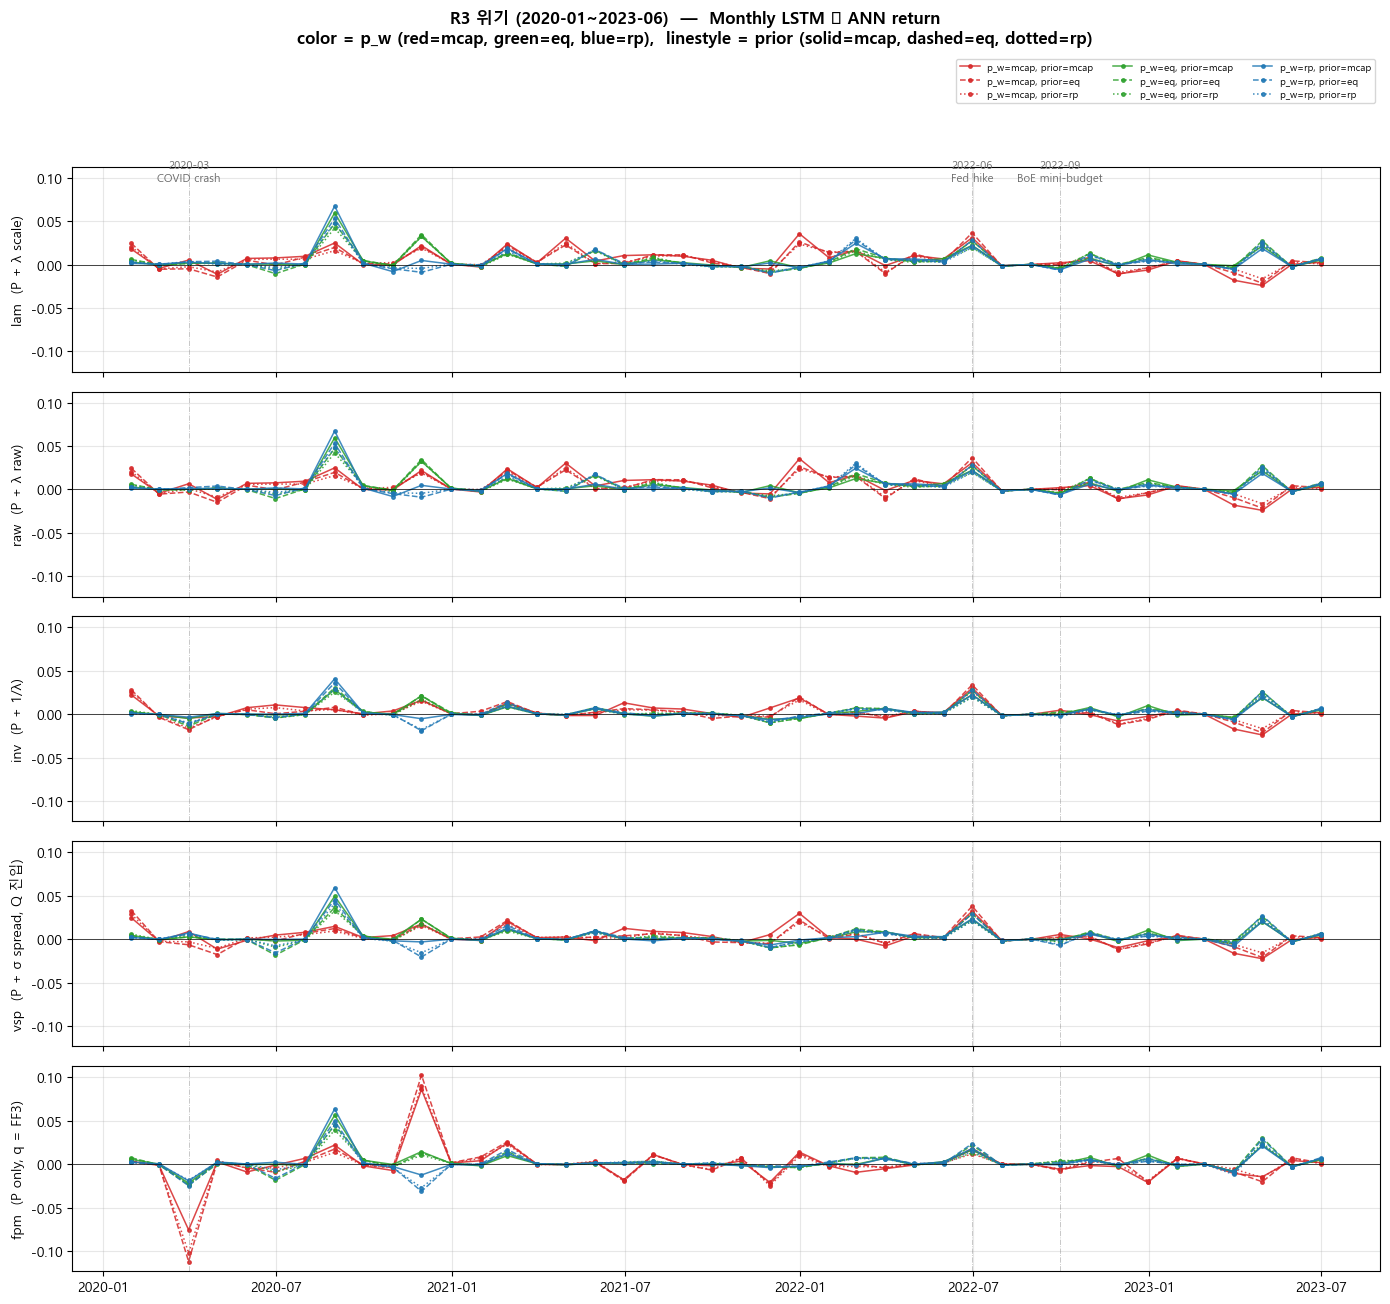

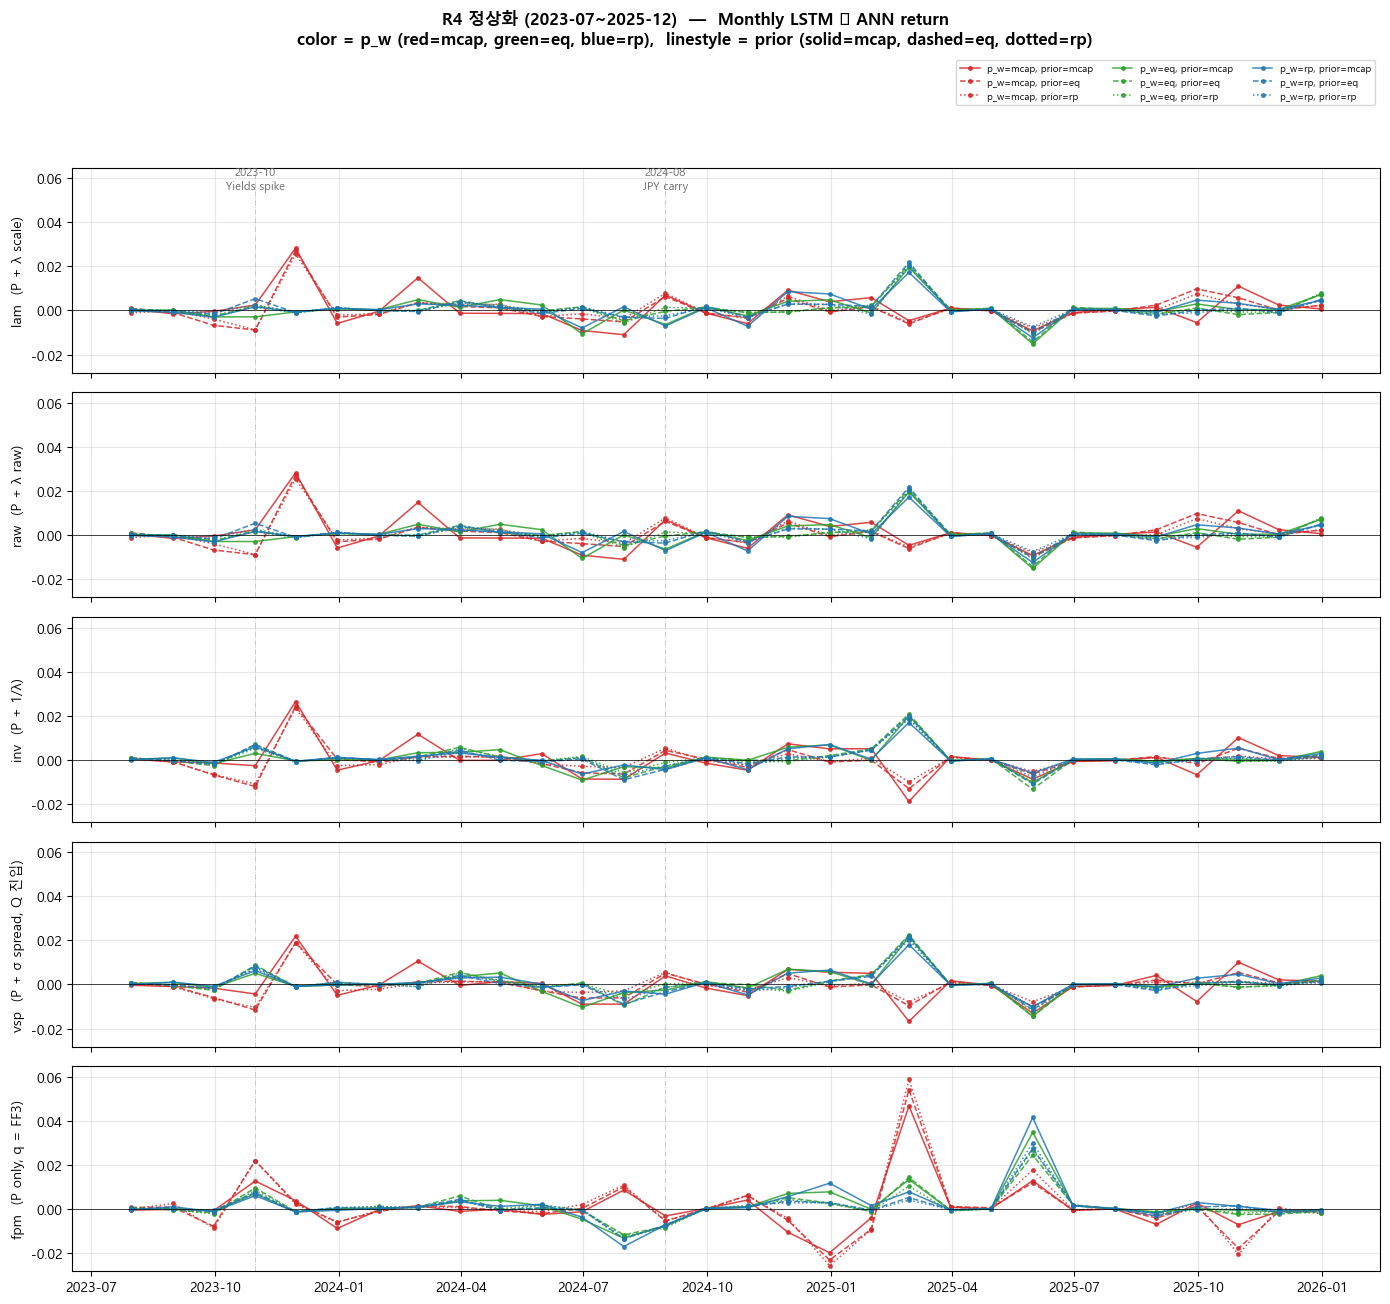

In [14]:
# ── [6] Q × regime × (prior × p_w) timeline — 9 라인 per subplot ──
REGIME_PERIODS = {
    'R1 회복 (2010-01~2012-06)':    (pd.Timestamp('2010-01-31'), pd.Timestamp('2012-06-30')),
    'R2 확장 (2012-07~2019-12)':    (pd.Timestamp('2012-07-31'), pd.Timestamp('2019-12-31')),
    'R3 위기 (2020-01~2023-06)':    (pd.Timestamp('2020-01-31'), pd.Timestamp('2023-06-30')),
    'R4 정상화 (2023-07~2025-12)':  (pd.Timestamp('2023-07-31'), pd.Timestamp('2025-12-31')),
}
REGIME_EVENTS = {
    'R1 회복 (2010-01~2012-06)': [('2010-05','Flash Crash'),('2011-03','Tohoku eq'),('2011-08','S&P downgrade')],
    'R2 확장 (2012-07~2019-12)': [('2015-08','CNY devalue'),('2018-02','Volmageddon'),('2018-12','Q4 selloff')],
    'R3 위기 (2020-01~2023-06)': [('2020-03','COVID crash'),('2022-06','Fed hike'),('2022-09','BoE mini-budget')],
    'R4 정상화 (2023-07~2025-12)': [('2023-10','Yields spike'),('2024-08','JPY carry')],
}
PRIORS=['mcap','eq','rp']; PW=['mcap','eq','rp']; Q=['lam','raw','inv','vsp','fpm']
Q_LABEL = {'lam':'lam  (P + λ scale)','raw':'raw  (P + λ raw)',
           'inv':'inv  (P + 1/λ)','vsp':'vsp  (P + σ spread, Q 진입)',
           'fpm':'fpm  (P only, q = FF3)'}
pw_colors = {'mcap':'#d62728', 'eq':'#2ca02c', 'rp':'#1f77b4'}
prior_styles = {'mcap':'-', 'eq':'--', 'rp':':'}   # solid / dashed / dotted

def build_one(start, end, q, pw, pr):
    L = f'mat_{pr}_{pw}_{q}_pap'; A = L + '_ann'
    if L not in loaded or A not in loaded: return pd.Series(dtype=float)
    rL = loaded[L]['ret'].dropna(); rA = loaded[A]['ret'].dropna()
    common = rL.index.intersection(rA.index)
    d = rL.loc[common] - rA.loc[common]
    d.index = d.index + pd.offsets.MonthEnd(1)
    return d[(d.index>=start)&(d.index<=end)]

# 평균표 (전체 9 슬롯 평균; reference)
print('='*86)
print('Q × regime 월평균 LSTM−ANN return  (각 셀: 3 prior × 3 p_w = 9 슬롯 평균)')
print('='*86)
print(f'{"Q":<8s}' + ''.join(f'{r.split()[0]:>16s}' for r in REGIME_PERIODS) + f'{"all (10y)":>14s}')
print('-'*86)
for q in Q:
    cells = []
    for label, (s, e) in REGIME_PERIODS.items():
        vals = []
        for pw in PW:
            for pr in PRIORS:
                vals.append(build_one(s,e,q,pw,pr).mean())
        cells.append(np.nanmean(vals))
    all_vals = []
    for pw in PW:
        for pr in PRIORS:
            L = f'mat_{pr}_{pw}_{q}_pap'; A = L+'_ann'
            if L not in loaded or A not in loaded: continue
            rL = loaded[L]['ret'].dropna(); rA = loaded[A]['ret'].dropna()
            common = rL.index.intersection(rA.index)
            all_vals.append((rL.loc[common]-rA.loc[common]).mean())
    print(f'{q:<8s}' + ''.join(f'{v:>+16.4f}' for v in cells) + f'{np.mean(all_vals):>+14.4f}')

# regime 별 figure — 5 Q rows × 1 col, 각 subplot 에 9 라인 (3 prior × 3 p_w)
for rlabel, (s, e) in REGIME_PERIODS.items():
    series = {q: {pw: {pr: build_one(s,e,q,pw,pr) for pr in PRIORS} for pw in PW} for q in Q}
    all_vals = [v for q in Q for pw in PW for pr in PRIORS for v in series[q][pw][pr].values]
    ymin, ymax = min(all_vals)*1.1, max(all_vals)*1.1

    fig, axes = plt.subplots(len(Q), 1, figsize=(14, 13), sharex=True)
    for i, q in enumerate(Q):
        ax = axes[i]
        for pw in PW:
            for pr in PRIORS:
                ser = series[q][pw][pr]
                if len(ser)==0: continue
                label = (f'p_w={pw}, prior={pr}' if i==0 else None)
                ax.plot(ser.index, ser.values,
                        color=pw_colors[pw], linestyle=prior_styles[pr],
                        lw=1.1, marker='o', markersize=2.5, alpha=0.85,
                        label=label)
        ax.axhline(0, color='black', lw=0.5)
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel(Q_LABEL[q], fontsize=10)
        ax.grid(True, alpha=0.3)
        for ym, ev in REGIME_EVENTS.get(rlabel, []):
            matches = [dt for dt in series[q]['mcap']['mcap'].index if dt.strftime('%Y-%m') == ym]
            if matches:
                dt = matches[0]
                ax.axvline(dt, color='gray', ls='-.', lw=0.6, alpha=0.5)
                if i == 0:
                    ax.annotate(f'{ym}\n{ev}', xy=(dt, ymax*0.85),
                                fontsize=8, ha='center', color='dimgray')

    axes[0].legend(loc='upper right', fontsize=7, ncol=3,
                    bbox_to_anchor=(1.0, 1.55))
    fig.suptitle(f'{rlabel}  —  Monthly LSTM − ANN return\n'
                  f'color = p_w (red=mcap, green=eq, blue=rp),  '
                  f'linestyle = prior (solid=mcap, dashed=eq, dotted=rp)',
                  fontsize=12, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


## [7] fpm Q 시계열 분석 — sign behavior

**목적**: σ-direct Q (lam/raw/inv/vsp) 와 fpm 의 본질적 차이를 데이터로 입증.

- σ-direct Q: λ scaling 으로 q 항상 양수 ("long low-vol / short high-vol" view 고정)
- fpm: FF3 OLS 평균으로 q 산출, **sign-flexible** (regime 따라 view 방향 바뀜)

**가설**:
- R4 (AI 랠리) 에서 fpm 우위 = q 가 음수로 → high-vol view 가 AI 종목 강세에 적합
- R3 에서 mcap-mcap-fpm 부진 = 위기에 high-vol view 가 손해

`mat_mcap_mcap_fpm_pap` 의 `meta['Q']` 시계열로 확인.


fpm Q value sign distribution by regime (calendar 정렬)
  q > 0 = long low-vol / short high-vol view
  q < 0 = long high-vol / short low-vol view (sign flip)
regime          n_mo      mean q      median     % q<0         min         max
------------------------------------------------------------------------------
All              192    -0.00224    -0.00127     63.0%    -0.02185    +0.01025
------------------------------------------------------------------------------
R1 회복             30    +0.00012    +0.00047     43.3%    -0.00414    +0.00460
R2 확장             90    -0.00105    -0.00121     61.1%    -0.00903    +0.00926
R3 위기             42    -0.00091    -0.00162     69.0%    -0.00960    +0.01025
R4 정상화            30    -0.01003    -0.01350     80.0%    -0.02185    +0.00479

참고: lam Q (σ-direct) 의 음수 비율
  All: 0.0%, mean=+0.00588
  → σ-direct 는 항상 양수, fpm 만 sign-flexible


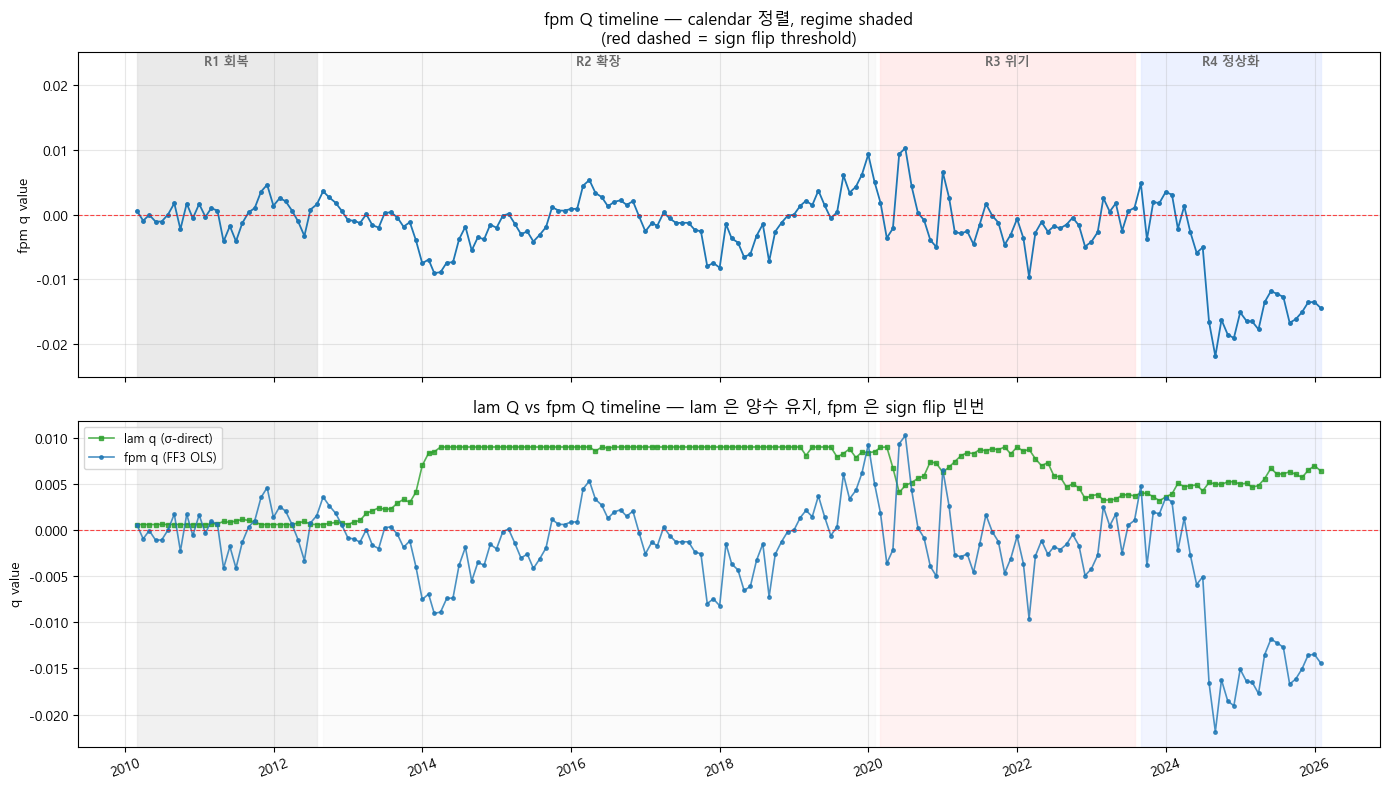

In [12]:
# ── [7] fpm Q 시계열 sign analysis ────────────────────────────
fpm_meta = loaded['mat_mcap_mcap_fpm_pap']['meta']
q_fpm = fpm_meta['Q'].copy()
q_fpm_cal = q_fpm.copy()
q_fpm_cal.index = q_fpm_cal.index + pd.offsets.MonthEnd(1)

REGIMES_T = {
    'R1 회복':   (pd.Timestamp('2010-02-28'), pd.Timestamp('2012-07-31')),
    'R2 확장':   (pd.Timestamp('2012-08-31'), pd.Timestamp('2020-01-31')),
    'R3 위기':   (pd.Timestamp('2020-02-29'), pd.Timestamp('2023-07-31')),
    'R4 정상화': (pd.Timestamp('2023-08-31'), pd.Timestamp('2026-01-31')),
}

print('='*80)
print('fpm Q value sign distribution by regime (calendar 정렬)')
print('  q > 0 = long low-vol / short high-vol view')
print('  q < 0 = long high-vol / short low-vol view (sign flip)')
print('='*80)
print(f'{"regime":<14s}{"n_mo":>6s}{"mean q":>12s}{"median":>12s}{"% q<0":>10s}{"min":>12s}{"max":>12s}')
print('-'*78)
all_neg = (q_fpm_cal < 0).mean()*100
print(f'{"All":<14s}{len(q_fpm_cal):>6d}{q_fpm_cal.mean():>+12.5f}{q_fpm_cal.median():>+12.5f}{all_neg:>9.1f}%{q_fpm_cal.min():>+12.5f}{q_fpm_cal.max():>+12.5f}')
print('-'*78)
for lbl, (s, e) in REGIMES_T.items():
    sub = q_fpm_cal[(q_fpm_cal.index>=s)&(q_fpm_cal.index<=e)]
    if len(sub)==0: continue
    neg_pct = (sub<0).mean()*100
    print(f'{lbl:<14s}{len(sub):>6d}{sub.mean():>+12.5f}{sub.median():>+12.5f}{neg_pct:>9.1f}%{sub.min():>+12.5f}{sub.max():>+12.5f}')

lam_meta = loaded['mat_mcap_mcap_lam_pap']['meta']
q_lam = lam_meta['Q'].copy()
q_lam_cal = q_lam.copy(); q_lam_cal.index = q_lam_cal.index + pd.offsets.MonthEnd(1)
print('\n참고: lam Q (σ-direct) 의 음수 비율')
print(f'  All: {(q_lam_cal<0).mean()*100:.1f}%, mean={q_lam_cal.mean():+.5f}')
print(f'  → σ-direct 는 항상 양수, fpm 만 sign-flexible')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
regime_colors = {'R1 회복':'#dddddd', 'R2 확장':'#f5f5f5', 'R3 위기':'#ffe0e0', 'R4 정상화':'#e0e8ff'}
ylim_buf = max(abs(q_fpm_cal.min()), abs(q_fpm_cal.max())) * 1.15
for lbl, (s, e) in REGIMES_T.items():
    ax.axvspan(s, e, color=regime_colors[lbl], alpha=0.6, zorder=0)
    mid = s + (e - s)/2
    ax.text(mid, ylim_buf*0.92, lbl, ha='center', fontsize=9, color='dimgray', fontweight='bold')
ax.plot(q_fpm_cal.index, q_fpm_cal.values, color='#1f77b4', lw=1.3, marker='o', markersize=2.5)
ax.axhline(0, color='red', lw=0.8, ls='--', alpha=0.7)
ax.set_ylabel('fpm q value')
ax.set_title('fpm Q timeline — calendar 정렬, regime shaded\n(red dashed = sign flip threshold)')
ax.set_ylim(-ylim_buf, ylim_buf)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(q_lam_cal.index, q_lam_cal.values, color='#2ca02c', lw=1.2, marker='s', markersize=2.5, label='lam q (σ-direct)', alpha=0.8)
ax.plot(q_fpm_cal.index, q_fpm_cal.values, color='#1f77b4', lw=1.2, marker='o', markersize=2.5, label='fpm q (FF3 OLS)', alpha=0.8)
ax.axhline(0, color='red', lw=0.8, ls='--', alpha=0.7)
for lbl, (s, e) in REGIMES_T.items():
    ax.axvspan(s, e, color=regime_colors[lbl], alpha=0.4, zorder=0)
ax.set_ylabel('q value')
ax.set_title('lam Q vs fpm Q timeline — lam 은 양수 유지, fpm 은 sign flip 빈번')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## [9] R4 mechanism — fpm q 부호별 bucket weight + AI 섹터 노출

**가설**:
1. **fpm q 음수 ↔ portfolio 가 high-vol 종목 over-weight** (BL view flip → long high-vol short low-vol)
2. **mcap prior → AI/Tech 섹터 over-weight** (대형주가 IT/Communication 섹터에 집중)

**확인 방법**:
1. fpm 슬롯 (`mat_mcap_mcap_fpm_pap`) 의 월별 q 값 (meta) + 그달 portfolio 의 low-vol bucket weight 합, high-vol bucket weight 합 → q<0 month 에서 high > low 인지 직접 확인
2. R4 의 각 prior (mcap/eq/rp) 별 fpm 슬롯 portfolio 의 **IT + Tech + Communication Services 섹터 weight 합** → prior=mcap 가 가장 높은지 확인


(1) fpm q 부호별 bucket weight — slot = mat_mcap_mcap_fpm_pap
    R4 (2023-07~2025-12) 의 월별 q 값과 portfolio 의 σ bucket weight
month         q_fpm  q sign   low30%w    hi30%w    hi−low
------------------------------------------------------------
2023-07    +0.00479   양 (+)    46.21%    10.33%   -35.88%
2023-08    -0.00382   음 (−)    34.86%    30.03%    -4.83%
2023-09    +0.00192   양 (+)    62.60%     0.51%   -62.09%
2023-10    +0.00177   양 (+)    46.24%    21.40%   -24.84%
2023-11    +0.00349   양 (+)    58.95%     6.08%   -52.87%
2023-12    +0.00305   양 (+)    44.09%    15.60%   -28.49%
2024-01    -0.00219   음 (−)    37.59%    22.43%   -15.16%
2024-02    +0.00129   양 (+)    54.92%    15.90%   -39.02%
2024-03    -0.00269   음 (−)    43.43%    11.94%   -31.49%
2024-04    -0.00590   음 (−)    25.98%    29.16%    +3.18%
2024-05    -0.00507   음 (−)    33.79%    21.05%   -12.74%
2024-06    -0.01656   음 (−)     8.99%    55.25%   +46.26%
2024-07    -0.02185   음 (−)    17.29%    37.86%   +20.57%
2024-

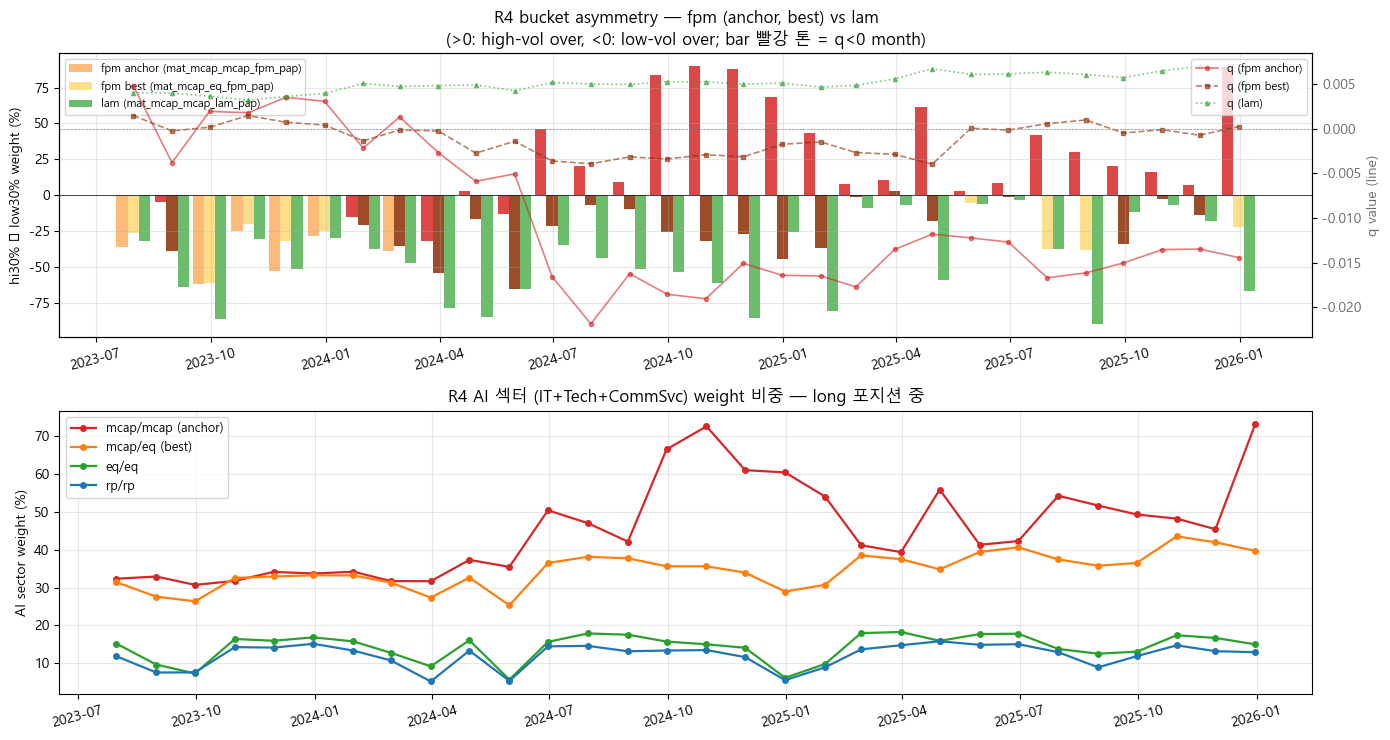

In [28]:
# ── [9] R4 mechanism — fpm q sign + AI 섹터 노출 ──────────────
R4_S = pd.Timestamp('2023-07-31')
R4_E = pd.Timestamp('2025-12-31')

# 데이터 준비
_lstm_raw = pd.read_csv(DATA_DIR/'03b_lstm/data/ensemble_predictions_stockwise.csv',
                          parse_dates=['date'])[['date','ticker','y_pred_ensemble']]
_lstm_raw['ym'] = _lstm_raw['date'].dt.to_period('M')
_lstm_m = _lstm_raw.sort_values('date').groupby(['ym','ticker'], as_index=False).last()
_lstm_m['date'] = _lstm_m['ym'].dt.to_timestamp(how='end').apply(
    lambda d: pd.Timestamp(d.year, d.month, 1) + pd.offsets.MonthEnd(0))
_lstm_pivot = _lstm_m.pivot(index='date', columns='ticker', values='y_pred_ensemble')

_panel_full = pd.read_csv(DATA_DIR/'monthly_panel.csv', parse_dates=['date'])
_panel_full['ym'] = _panel_full['date'].dt.to_period('M')
AI_SECTORS = {'Information Technology', 'Technology', 'Communication Services'}
_sector_map = (_panel_full.dropna(subset=['gics_sector'])
                 .groupby('ticker')['gics_sector']
                 .agg(lambda s: s.mode().iloc[0] if len(s.mode())>0 else 'Unknown')
                 .to_dict())

# ── (1) fpm Q 부호별 bucket weight — slot = mat_mcap_mcap_fpm_pap (anchor) ──
slot = 'mat_mcap_mcap_fpm_pap'
w_all = loaded[slot]['weights']
meta = loaded[slot]['meta']
q_series = meta['Q']
w_r4 = w_all[(w_all.index>=R4_S)&(w_all.index<=R4_E)]

print('='*72)
print(f'(1) fpm q 부호별 bucket weight — slot = {slot}')
print(f'    R4 (2023-07~2025-12) 의 월별 q 값과 portfolio 의 σ bucket weight')
print('='*72)
print(f'{"month":<9s}{"q_fpm":>10s}{"q sign":>8s}{"low30%w":>10s}{"hi30%w":>10s}{"hi−low":>10s}')
print('-'*60)

q_sign_rows = []
for dt in w_r4.index:
    wt = w_r4.loc[dt].dropna()
    sig = _lstm_pivot.loc[dt] if dt in _lstm_pivot.index else None
    q_val = q_series.get(dt, np.nan)
    if sig is None or pd.isna(q_val): continue
    common = wt.index.intersection(sig.dropna().index)
    if len(common) < 10: continue
    sig_c = sig.loc[common]
    n_b = max(1, int(len(sig_c)*0.30))
    w_lo = wt.loc[sig_c.nsmallest(n_b).index].sum()
    w_hi = wt.loc[sig_c.nlargest(n_b).index].sum()
    qsg = '음 (−)' if q_val < 0 else '양 (+)'
    print(f'{dt.strftime("%Y-%m"):<9s}{q_val:>+10.5f}{qsg:>8s}{w_lo*100:>9.2f}%{w_hi*100:>9.2f}%{(w_hi-w_lo)*100:>+9.2f}%')
    q_sign_rows.append(dict(date=dt, q=q_val, w_lo=w_lo, w_hi=w_hi))

qdf = pd.DataFrame(q_sign_rows)
neg = qdf[qdf['q']<0]; pos = qdf[qdf['q']>=0]
print(f'\n  q<0 month (n={len(neg)}): avg hi−low = {(neg["w_hi"]-neg["w_lo"]).mean()*100:+.2f}%  ← 음수 q → high-vol over')
print(f'  q≥0 month (n={len(pos)}): avg hi−low = {(pos["w_hi"]-pos["w_lo"]).mean()*100:+.2f}%  ← 양수 q → low-vol over')

# ── (1.5) LSTM-best slot — mat_mcap_eq_fpm_pap ─────────────
slot_me = 'mat_mcap_eq_fpm_pap'
w_me_all = loaded[slot_me]['weights']
meta_me = loaded[slot_me]['meta']
q_me_series = meta_me['Q']
w_me_r4 = w_me_all[(w_me_all.index>=R4_S)&(w_me_all.index<=R4_E)]

print('\n' + '='*72)
print(f'(1.5) LSTM-best slot — slot = {slot_me}  (prior=mcap, p_w=eq)')
print(f'      anchor 와 같은 Q (fpm) 이지만 p_w 가 eq 라 q magnitude 작음')
print('='*72)
print(f'{"month":<9s}{"q_fpm":>10s}{"q sign":>8s}{"low30%w":>10s}{"hi30%w":>10s}{"hi−low":>10s}')
print('-'*60)

me_rows = []
for dt in w_me_r4.index:
    wt = w_me_r4.loc[dt].dropna()
    sig = _lstm_pivot.loc[dt] if dt in _lstm_pivot.index else None
    q_val = q_me_series.get(dt, np.nan)
    if sig is None or pd.isna(q_val): continue
    common = wt.index.intersection(sig.dropna().index)
    if len(common) < 10: continue
    sig_c = sig.loc[common]
    n_b = max(1, int(len(sig_c)*0.30))
    w_lo = wt.loc[sig_c.nsmallest(n_b).index].sum()
    w_hi = wt.loc[sig_c.nlargest(n_b).index].sum()
    qsg = '음 (−)' if q_val < 0 else '양 (+)'
    print(f'{dt.strftime("%Y-%m"):<9s}{q_val:>+10.5f}{qsg:>8s}{w_lo*100:>9.2f}%{w_hi*100:>9.2f}%{(w_hi-w_lo)*100:>+9.2f}%')
    me_rows.append(dict(date=dt, q=q_val, w_lo=w_lo, w_hi=w_hi))

medf = pd.DataFrame(me_rows)
me_neg = medf[medf['q']<0]; me_pos = medf[medf['q']>=0]
print(f'\n  q<0 month (n={len(me_neg)}): avg hi−low = {(me_neg["w_hi"]-me_neg["w_lo"]).mean()*100:+.2f}%')
print(f'  q≥0 month (n={len(me_pos)}): avg hi−low = {(me_pos["w_hi"]-me_pos["w_lo"]).mean()*100:+.2f}%')
print(f'  비교 (anchor mcap_mcap vs best mcap_eq):')
print(f'    q magnitude: anchor mean {qdf["q"].mean():+.5f},  best mean {medf["q"].mean():+.5f}  ({abs(qdf["q"].mean()/medf["q"].mean()):.1f}x 차이)')
print(f'    → best slot 의 view 가 약해서 prior 효과 흡수, q sign 이 bucket 방향 못 뒤집음')

# ── (1b) 대조: σ-direct Q (lam) — same family ───────────────
slot_lam = 'mat_mcap_mcap_lam_pap'
w_lam_all = loaded[slot_lam]['weights']
meta_lam = loaded[slot_lam]['meta']
q_lam_series = meta_lam['Q']
w_lam_r4 = w_lam_all[(w_lam_all.index>=R4_S)&(w_lam_all.index<=R4_E)]

print('\n' + '='*72)
print(f'(1b) 대조 — σ-direct Q (lam) slot = {slot_lam}')
print(f'      lam Q 는 λ scaling 으로 항상 q>0 → long low-vol view 유지')
print('='*72)
print(f'{"month":<9s}{"q_lam":>10s}{"q sign":>8s}{"low30%w":>10s}{"hi30%w":>10s}{"hi−low":>10s}')
print('-'*60)

lam_rows = []
for dt in w_lam_r4.index:
    wt = w_lam_r4.loc[dt].dropna()
    sig = _lstm_pivot.loc[dt] if dt in _lstm_pivot.index else None
    q_val = q_lam_series.get(dt, np.nan)
    if sig is None or pd.isna(q_val): continue
    common = wt.index.intersection(sig.dropna().index)
    if len(common) < 10: continue
    sig_c = sig.loc[common]
    n_b = max(1, int(len(sig_c)*0.30))
    w_lo = wt.loc[sig_c.nsmallest(n_b).index].sum()
    w_hi = wt.loc[sig_c.nlargest(n_b).index].sum()
    qsg = '양 (+)' if q_val >= 0 else '음 (−)'
    print(f'{dt.strftime("%Y-%m"):<9s}{q_val:>+10.5f}{qsg:>8s}{w_lo*100:>9.2f}%{w_hi*100:>9.2f}%{(w_hi-w_lo)*100:>+9.2f}%')
    lam_rows.append(dict(date=dt, q=q_val, w_lo=w_lo, w_hi=w_hi))

lamdf = pd.DataFrame(lam_rows)
print(f'\n  R4 평균 hi−low = {(lamdf["w_hi"]-lamdf["w_lo"]).mean()*100:+.2f}%  ← 양수 q → low-vol over 유지')
print('\n  요약 — fpm sign-flexibility vs lam sign-fixed:')
print(f'    fpm q<0:  hi−low = {(neg["w_hi"]-neg["w_lo"]).mean()*100:+.2f}%  (long high-vol)')
print(f'    fpm q≥0:  hi−low = {(pos["w_hi"]-pos["w_lo"]).mean()*100:+.2f}%  (long low-vol)')
print(f'    lam (q+): hi−low = {(lamdf["w_hi"]-lamdf["w_lo"]).mean()*100:+.2f}%  (long low-vol)')

# ── (1c) 대표 R4 month 의 top 10 weighted 종목 — fpm vs lam ──
target_dt = qdf.loc[qdf['q'].idxmin(), 'date']
target_q = qdf['q'].min()
w_fpm_t = w_r4.loc[target_dt].dropna().sort_values(ascending=False)
w_lam_t = w_lam_r4.loc[target_dt].dropna().sort_values(ascending=False)
sig_t = _lstm_pivot.loc[target_dt] if target_dt in _lstm_pivot.index else pd.Series()
next_ym = (target_dt + pd.offsets.MonthEnd(1)).to_period('M')
real_ret = _panel_full[_panel_full['ym']==next_ym].set_index('ticker')['fwd_ret_1m']

print('\n' + '='*72)
print(f'(1c) 대표 month = {target_dt.strftime("%Y-%m")}  (fpm q={target_q:+.5f}, R4 최저)')
print(f'     top 10 long weighted 종목 — fpm vs lam 비교')
print('='*72)
def _print_top(label, w_series):
    print(f'\n[{label}]')
    print(f'  {"ticker":<8s}{"weight":>9s}{"σ_pred":>10s}{"sector":>26s}{"next_ret":>11s}')
    for tk, w in w_series.head(10).items():
        sig_v = sig_t.get(tk, np.nan)
        sec = _sector_map.get(tk, 'Unknown')[:26]
        r = real_ret.get(tk, np.nan)
        r_str = f'{r*100:+.2f}%' if not pd.isna(r) else '  —  '
        print(f'  {tk:<8s}{w*100:>8.2f}%{sig_v:>10.4f}{sec:>26s}{r_str:>11s}')

_print_top(f'fpm slot ({slot})', w_fpm_t)
_print_top(f'lam slot ({slot_lam})', w_lam_t)
ovl = set(w_fpm_t.head(10).index) & set(w_lam_t.head(10).index)
print(f'\n  top10 overlap: {len(ovl)} 종목 — {sorted(ovl)}')
print(f'  fpm only: {sorted(set(w_fpm_t.head(10).index) - set(w_lam_t.head(10).index))}')
print(f'  lam only: {sorted(set(w_lam_t.head(10).index) - set(w_fpm_t.head(10).index))}')

# ── (2) prior 별 AI 섹터 노출 — fpm 4 슬롯 ─────────────────
fpm_slots = {
    'mat_mcap_mcap_fpm_pap': 'mcap/mcap (anchor)',
    'mat_mcap_eq_fpm_pap':   'mcap/eq (best)',
    'mat_eq_eq_fpm_pap':     'eq/eq',
    'mat_rp_rp_fpm_pap':     'rp/rp',
}
print('\n' + '='*72)
print('(2) prior/p_w 별 AI 섹터 (IT+Tech+CommSvc) weight 비중 — R4 fpm 슬롯')
print('='*72)
ai_by_slot = {}
for sn, lbl in fpm_slots.items():
    if sn not in loaded: continue
    ws = loaded[sn]['weights']
    wr = ws[(ws.index>=R4_S)&(ws.index<=R4_E)]
    shares = []
    for dt in wr.index:
        wt = wr.loc[dt].dropna()
        pos_w = wt[wt>0]
        ai = pos_w[[t for t in pos_w.index if _sector_map.get(t,'') in AI_SECTORS]]
        shares.append((dt, ai.sum()/pos_w.sum() if pos_w.sum()>0 else 0))
    ai_by_slot[sn] = shares
    print(f'  {lbl:<22s}: R4 평균 AI 섹터 비중 = {np.mean([s for _,s in shares])*100:.1f}%')

# ── 시각화: 2 panel ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7.5))

ax = axes[0]
w_days = 9
qdf_s = qdf.sort_values('date'); medf_s = medf.sort_values('date'); lamdf_s = lamdf.sort_values('date')
ax.bar(qdf_s['date'] - pd.Timedelta(days=w_days),
       (qdf_s['w_hi']-qdf_s['w_lo'])*100, width=w_days,
       color=['#d62728' if q<0 else '#fdae61' for q in qdf_s['q']],
       alpha=0.85, label=f'fpm anchor ({slot})')
ax.bar(medf_s['date'],
       (medf_s['w_hi']-medf_s['w_lo'])*100, width=w_days,
       color=['#8c2d04' if q<0 else '#fed976' for q in medf_s['q']],
       alpha=0.85, label=f'fpm best ({slot_me})')
ax.bar(lamdf_s['date'] + pd.Timedelta(days=w_days),
       (lamdf_s['w_hi']-lamdf_s['w_lo'])*100, width=w_days,
       color='#2ca02c', alpha=0.7, label=f'lam ({slot_lam})')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('hi30% − low30% weight (%)')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=15)
ax.set_title('R4 bucket asymmetry — fpm (anchor, best) vs lam\n'
             '(>0: high-vol over, <0: low-vol over; bar 빨강 톤 = q<0 month)')

# q 값 secondary axis overlay
ax2 = ax.twinx()
ax2.plot(qdf_s['date'], qdf_s['q'], color='#d62728', lw=1.2, marker='o', markersize=3,
          alpha=0.6, label='q (fpm anchor)')
ax2.plot(medf_s['date'], medf_s['q'], color='#8c2d04', lw=1.2, marker='s', markersize=3,
          alpha=0.6, linestyle='--', label='q (fpm best)')
ax2.plot(lamdf_s['date'], lamdf_s['q'], color='#2ca02c', lw=1.2, marker='^', markersize=3,
          alpha=0.6, linestyle=':', label='q (lam)')
ax2.axhline(0, color='gray', lw=0.5, ls='--')
ax2.set_ylabel('q value (line)', color='dimgray')
ax2.tick_params(axis='y', labelcolor='dimgray')
ax2.legend(loc='upper right', fontsize=8)

ax = axes[1]
colors_p = {'mat_mcap_mcap_fpm_pap':'#d62728', 'mat_mcap_eq_fpm_pap':'#ff7f0e',
            'mat_eq_eq_fpm_pap':'#2ca02c', 'mat_rp_rp_fpm_pap':'#1f77b4'}
for sn, lbl in fpm_slots.items():
    if sn not in ai_by_slot: continue
    dts = [d for d,_ in ai_by_slot[sn]]
    vals = [v*100 for _,v in ai_by_slot[sn]]
    ax.plot(dts, vals, lw=1.6, marker='o', markersize=4,
             color=colors_p.get(sn,'gray'), label=lbl)
ax.set_title('R4 AI 섹터 (IT+Tech+CommSvc) weight 비중 — long 포지션 중')
ax.set_ylabel('AI sector weight (%)')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
